In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import glob # to load engagement files
import seaborn as sns
import os
import re
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from matplotlib.ticker import MultipleLocator
import datetime
import gc
import plotly.express as px
from plotly.subplots import make_subplots
from plotly.graph_objs.layout import YAxis,XAxis,Margin
import warnings
warnings.filterwarnings("ignore")
import matplotlib
from matplotlib.ticker import FuncFormatter
matplotlib.rcParams['figure.figsize'] = (10, 6)



#**Tổng quan chung về tình hình giáo dục nước Mỹ vào năm 2020**

In [10]:
df= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/products_info.csv')
df

,LP ID,URL,Product Name,Provider/Company Name,Sector(s),Primary Essential Function
0,13117,https://www.splashmath.com,SplashLearn,StudyPad Inc.,PreK-12,LC - Digital Learning Platforms
1,66933,https://abcmouse.com,ABCmouse.com,"Age of Learning, Inc",PreK-12,LC - Digital Learning Platforms
2,50479,https://www.abcya.com,ABCya!,"ABCya.com, LLC",PreK-12,"LC - Sites, Resources & Reference - Games & Si..."
3,92993,http://www.aleks.com/,ALEKS,McGraw-Hill PreK-12,PreK-12; Higher Ed,LC - Digital Learning Platforms
4,73104,https://www.achieve3000.com/,Achieve3000,Achieve3000,PreK-12,LC - Digital Learning Platforms
...,...,...,...,...,...,...
367,88065,https://dochub.com/,DocHub,DocHub,PreK-12; Higher Ed; Corporate,SDO - Other
368,37805,http://google.com/slides/about/,Google Slides,Google LLC,PreK-12; Higher Ed; Corporate,LC - Content Creation & Curation
369,32555,http://www.innersloth.com/gameAmongUs.php,Among Us,InnerSloth,PreK-12; Higher Ed,"LC - Sites, Resources & Reference - Games & Si..."
370,87841,http://edpuzzle.com,Edpuzzle - Free (Basic Plan),EDpuzzle Inc.,NaN,NaN


In [11]:
lc= df['Primary Essential Function'].dropna()
lc.value_counts()

LC - Digital Learning Platforms                                              74
LC - Sites, Resources & Reference                                            47
LC - Content Creation & Curation                                             36
LC - Study Tools                                                             25
LC - Courseware & Textbooks                                                  18
LC - Sites, Resources & Reference - Games & Simulations                      18
LC/CM/SDO - Other                                                            16
LC - Sites, Resources & Reference - Digital Collection & Repository          15
CM - Classroom Engagement & Instruction - Classroom Management               11
LC - Sites, Resources & Reference - Streaming Services                        9
CM - Virtual Classroom - Video Conferencing & Screen Sharing                  7
LC - Study Tools - Q&A                                                        6
SDO - Data, Analytics & Reporting - Site

In [13]:
# Dữ liệu
SuKien = {
    'Ngày tháng': ["29/01/2020", "25/02/2020", "03/05/2020", "03/11/2020", "16/03/2020", "25/03/2020" ,"05/07/2020", "9/2020" ,"11/07/2020", "12/8/2020", "28/12/2020"],
    'Sự kiện': ["Ca nhiễm đầu tiên tại Hoa Kỳ","Các trường học lo ngại về khả năng học trực tuyến", "Bắt đầu học trực tuyến ở một số vùng", "WHO tuyên bố đại dịch, một số trường học đóng cửa","50% số học sinh bị ảnh hưởng", "Tất cả trường học công lập đóng cửa", "80% giáo viên tương tác hàng ngày hoặc hàng tuần với học sinh", "Hầu hết các học khu chọn học từ xa","Joe Biden được bầu làm tổng thống thứ 46 của Hoa Kỳ", "Biden cam kết mở cửa trường học", "Bắt đầu tiêm chủng cho giáo viên",],
    'Level' : [-3, -1, -4, 3, -6, 5, -5, 3, -3, 4, -5]
}

SuKien = pd.DataFrame(SuKien)
SuKien['Ngày tháng'] = pd.to_datetime(SuKien['Ngày tháng'])
SuKien

,Ngày tháng,Sự kiện,Level
0,2020-01-29,Ca nhiễm đầu tiên tại Hoa Kỳ,-3
1,2020-02-25,Các trường học lo ngại về khả năng học trực tuyến,-1
2,2020-03-05,Bắt đầu học trực tuyến ở một số vùng,-4
3,2020-03-11,"WHO tuyên bố đại dịch, một số trường học đóng cửa",3
4,2020-03-16,50% số học sinh bị ảnh hưởng,-6
5,2020-03-25,Tất cả trường học công lập đóng cửa,5
6,2020-05-07,80% giáo viên tương tác hàng ngày hoặc hàng tu...,-5
7,2020-09-01,Hầu hết các học khu chọn học từ xa,3
8,2020-11-07,Joe Biden được bầu làm tổng thống thứ 46 của H...,-3
9,2020-12-08,Biden cam kết mở cửa trường học,4


Text(0.5, 1.0, 'Tổng quan chung về tình hình giáo dục nước Mỹ vào năm 2020')

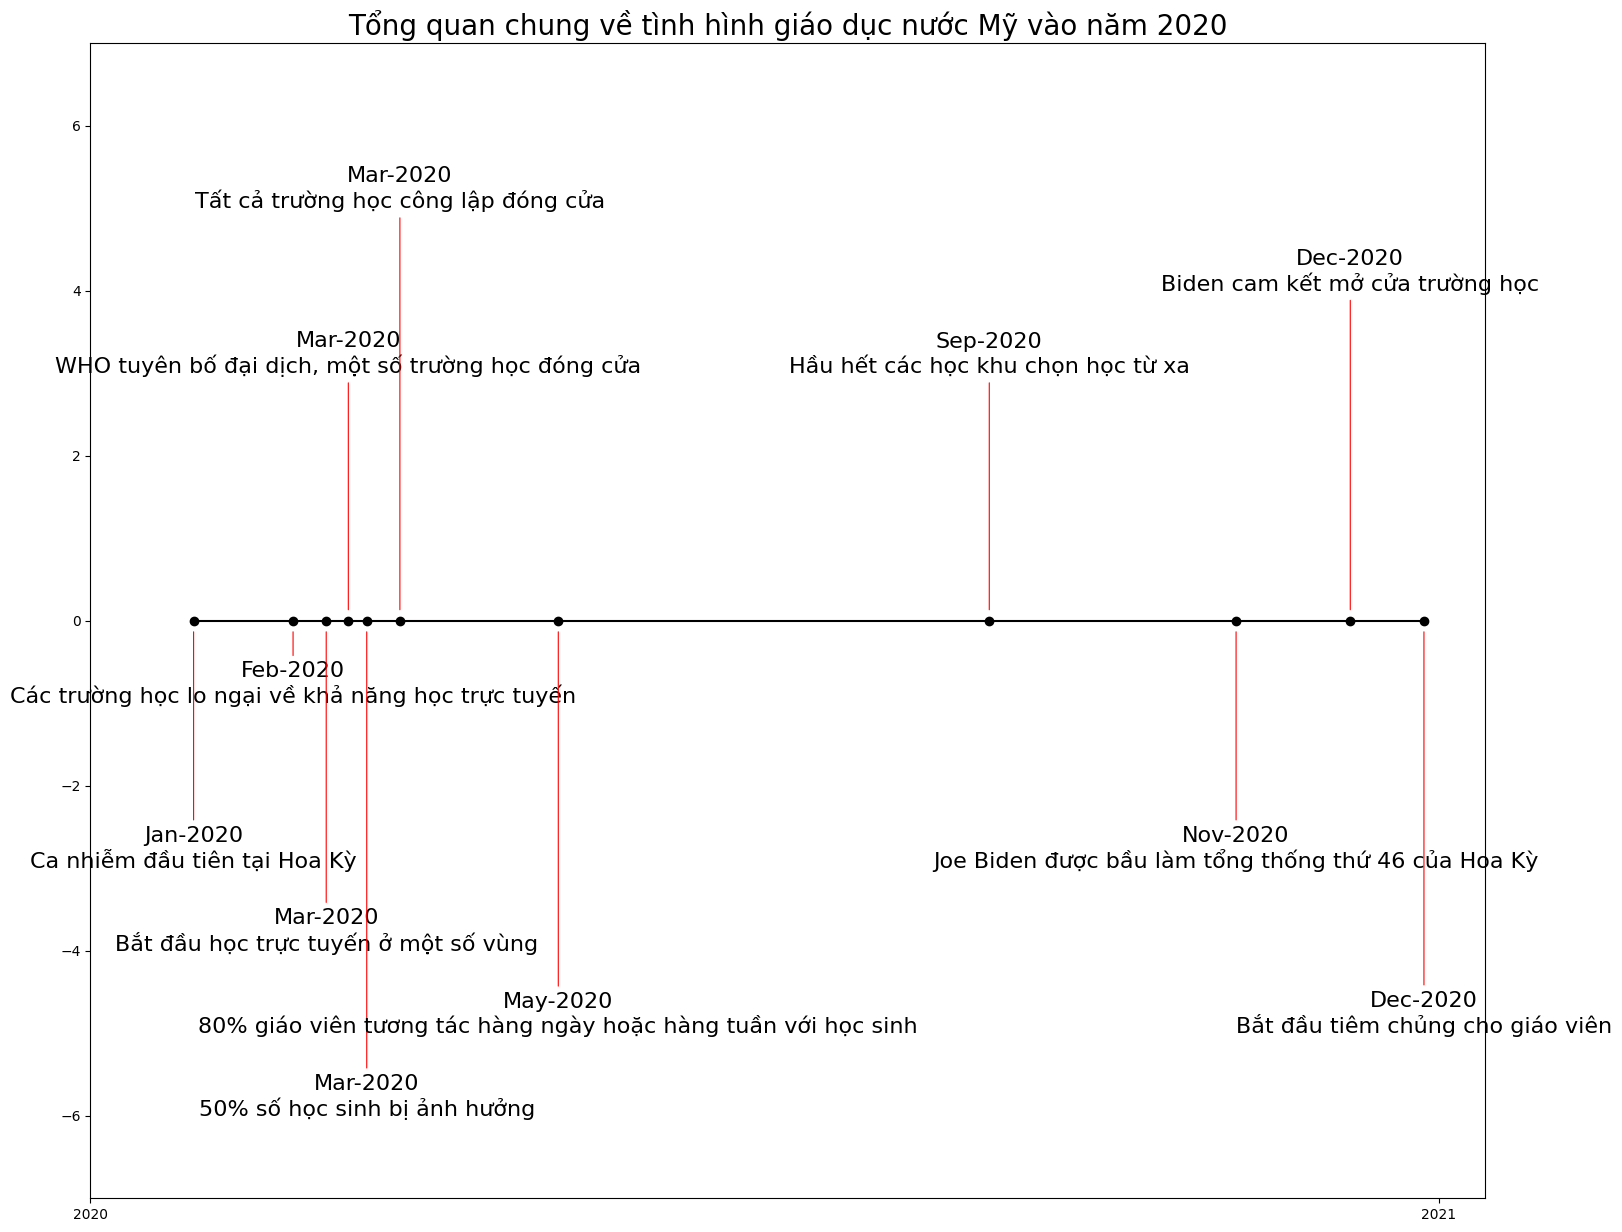

In [14]:
fig, ax = plt.subplots(figsize=(18,15))
ax.plot(SuKien['Ngày tháng'], [0,]*len(SuKien), "-o", color= 'black');
ax.set_xticks(pd.date_range("2020-01-01", "2021-01-01", freq="ys"), range(2020, 2022));
ax.set_ylim(-7,7)
for idx in range(len(SuKien)):
    day, event, level = SuKien['Ngày tháng'][idx], SuKien['Sự kiện'][idx], SuKien['Level'][idx]
    day_str = day.strftime("%b-%Y")
    ax.annotate(day_str + "\n" + event, xy =(day, 0.1 if level >0 else -0.1), xytext= (day, level),
                arrowprops= dict(arrowstyle = "-", color = "red", linewidth= 0.8),
                ha = "center", fontsize=16)
plt.title("Tổng quan chung về tình hình giáo dục nước Mỹ vào năm 2020", fontsize=20)

### Nhận xét
- **Biểu Đồ Thời Gian:** Timeline thể hiện một chuỗi các sự kiện quan trọng, cung cấp cái nhìn tổng quan về trình tự và ảnh hưởng của chúng đối với giáo dục.
- **Sự Kiện Đáng Chú Ý:** Các sự kiện được đánh dấu trên timeline cho thấy sự phát triển của tình hình dịch bệnh và các biện pháp phản ứng của ngành giáo dục.
- **Ảnh Hưởng Đến Giáo Dục:** Timeline cho thấy cách mà đại dịch đã ảnh hưởng đến việc học từ xa và các quyết định liên quan đến việc mở cửa trở lại các trường học.

#**1. Bức tranh về kết nối và tương tác kỹ thuật số trong năm 2020**

**1.1 Phân phối sản phẩm trong các nhóm LC, CM và SDO**

In [48]:
#Đọc file theo đường dẫn drive
product_df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/products_info.csv')
district_df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/districts_info.csv')
districts_info = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/districts_info.csv")
engagement_df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/engagement_data.csv')
engagement_df1=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/engagement_data.csv')

In [49]:
product_df.head()

,LP ID,URL,Product Name,Provider/Company Name,Sector(s),Primary Essential Function
0,13117,https://www.splashmath.com,SplashLearn,StudyPad Inc.,PreK-12,LC - Digital Learning Platforms
1,66933,https://abcmouse.com,ABCmouse.com,"Age of Learning, Inc",PreK-12,LC - Digital Learning Platforms
2,50479,https://www.abcya.com,ABCya!,"ABCya.com, LLC",PreK-12,"LC - Sites, Resources & Reference - Games & Si..."
3,92993,http://www.aleks.com/,ALEKS,McGraw-Hill PreK-12,PreK-12; Higher Ed,LC - Digital Learning Platforms
4,73104,https://www.achieve3000.com/,Achieve3000,Achieve3000,PreK-12,LC - Digital Learning Platforms


In [50]:
# Đổi tên cột về dạng thường và thay dấu cách bằng "_"
product_df.columns = [f"{re.sub(' ', '_', col.lower())}" for col in product_df.columns]

In [51]:
product_df.columns

Index(['lp_id', 'url', 'product_name', 'provider/company_name', 'sector(s)',
       'primary_essential_function'],
      dtype='object')

In [52]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   lp_id                       372 non-null    int64 
 1   url                         372 non-null    object
 2   product_name                372 non-null    object
 3   provider/company_name       371 non-null    object
 4   sector(s)                   352 non-null    object
 5   primary_essential_function  352 non-null    object
dtypes: int64(1), object(5)
memory usage: 17.6+ KB


In [53]:
product_df = product_df.dropna()#Loại bỏ NaN
product_df

,lp_id,url,product_name,provider/company_name,sector(s),primary_essential_function
0,13117,https://www.splashmath.com,SplashLearn,StudyPad Inc.,PreK-12,LC - Digital Learning Platforms
1,66933,https://abcmouse.com,ABCmouse.com,"Age of Learning, Inc",PreK-12,LC - Digital Learning Platforms
2,50479,https://www.abcya.com,ABCya!,"ABCya.com, LLC",PreK-12,"LC - Sites, Resources & Reference - Games & Si..."
3,92993,http://www.aleks.com/,ALEKS,McGraw-Hill PreK-12,PreK-12; Higher Ed,LC - Digital Learning Platforms
4,73104,https://www.achieve3000.com/,Achieve3000,Achieve3000,PreK-12,LC - Digital Learning Platforms
...,...,...,...,...,...,...
365,22241,https://www.history.com/,History.com,"A&E Television Networks, LLC",PreK-12; Higher Ed,"LC - Sites, Resources & Reference"
366,93376,https://www.cultofpedagogy.com/,Cult of Pedagogy,Cult of Pedagogy,PreK-12,CM - Teacher Resources - Professional Learning
367,88065,https://dochub.com/,DocHub,DocHub,PreK-12; Higher Ed; Corporate,SDO - Other
368,37805,http://google.com/slides/about/,Google Slides,Google LLC,PreK-12; Higher Ed; Corporate,LC - Content Creation & Curation


## Làm sạch dữ liệu
- Xóa các quận không có thông tin tiểu bang
- Xóa các quận có dữ liệu tương tác năm 2020 không đầy đủ
- Xóa các hàng trong dữ liệu tương tác không có trong sản phẩm_thông tin (8417 sản phẩm trong dữ liệu tương tác nhưng chỉ có 369 sản phẩm trong bảng sản phẩm)
- Tách các cột ‘Primary Essential Function’ thành 'Category' và 'SubCategory'
- Chỉ xem xét các quận có đầy đủ dữ liệu tham gia năm 2020
- Chỉ xem xét dữ liệu tương tác với lp_id trong Products_info
- Thêm mới cột tuần trong bảng engagement_df
- Vì county_connections_ratio đa phần có giá trị [0.18, 1] và có gtri ngoại lai là [1,2] nên không sử dụng cột này
- Chọn giá trị tb của 2 giá trị trong các cột pct_black/hispanic, pct_free/reduced, pp_total_raw.



In [54]:
# Xóa các quận không có thông tin tiểu bang
district_df = district_df[district_df.state.notna()].reset_index(drop=True)
# Tách các cột ‘Primary Essential Function’ thành 'Category' và 'SubCategory'
product_df['Category'] = product_df['primary_essential_function'].apply(lambda x: x.split(' - ')[0] if x == x else x)
product_df['SubCategory'] = product_df['primary_essential_function'].apply(lambda x: x.split(' - ')[1] if x == x else x)

# Xóa các quận có dữ liệu tương tác năm 2020 không đầy đủ
district_df= district_df[district_df.district_id.isin(engagement_df.district_id.unique())].reset_index(drop=True)
# Xóa các hàng trong dữ liệu tương tác không có trong sản phẩm_thông tin (có 369 sản phẩm trong bảng sản phẩm)
product_df = product_df[product_df.lp_id.isin(engagement_df.lp_id.unique())].reset_index(drop=True)
engagement_df= engagement_df[engagement_df.lp_id.isin(product_df.lp_id.unique())].reset_index(drop=True)
engagement_df.time = engagement_df.time.astype('datetime64[ns]')

# Thêm cột tuần
engagement_df['cw'] = pd.DatetimeIndex(engagement_df['time']).week
# Lấy mẫu lại dữ liệu trung bình hàng tuần
engagement_cw = engagement_df.groupby(['cw', 'lp_id', 'district_id'])[['pct_access', 'engagement_index']].mean().reset_index(drop=False)
# Thêm cột giai đoạn covid
engagement_cw['covid_phase'] = engagement_cw.cw.apply(lambda x: 1 if x < 10 else (4 if x > 35 else (3 if ((x>=10) & (x <=25)) else 1)))

In [55]:
# Chọn giá trị tb của 2 giá trị trong các cột pct_black/hispanic, pct_free/reduced, pp_total_raw.
mapping_dict = {'[0, 0.2[':0.1,
                '[0.2, 0.4[':0.3,
                '[0.4, 0.6[':0.5,
                '[0.6, 0.8[':0.7,
                '[0.8, 1[':0.9,
                np.nan:np.nan}
district_df['pct_black/hispanic'] = district_df['pct_black/hispanic'].map(mapping_dict)
district_df['pct_free/reduced'] = district_df['pct_free/reduced'].map(mapping_dict)
pp_total_dict = {np.nan:np.nan,
                '[8000, 10000[':9000,
                '[10000, 12000[':11000,
                '[14000, 16000[':15000,
                '[12000, 14000[':13000,
                '[16000, 18000[':17000,
                '[6000, 8000[':7000,
                '[18000, 20000[':19000,
                '[20000, 22000[':21000,
                '[22000, 24000[':23000,
                '[4000, 6000[':5000,
                '[32000, 34000[':33000}
district_df['pp_total_raw'] = district_df['pp_total_raw'].map(pp_total_dict)

In [56]:
#Gộp các subcategory tương tự nhau
def consolidate_subcategories(row):
    category = row['primary_essential_function']
    if pd.notna(category):  # Kiểm tra xem giá trị không phải NaN
        if 'CM - Classroom Engagement & Instruction' in category:
            return 'CM - Classroom Engagement & Instruction'
        elif 'CM - Teacher Resources' in category:
            return 'CM - Teacher Resources'
        elif 'CM - Virtual Classroom' in category:
            return 'CM - Virtual Classroom'
        elif 'LC - Sites, Resources & Reference' in category:
            return 'LC - Sites, Resources & Reference'
        elif 'SDO - Data, Analytics & Reporting' in category:
            return 'SDO - Data, Analytics & Reporting'
        elif 'LC - Study Tools' in category:
            return 'LC - Study Tools'
        elif 'SDO - School Management Software' in category:
            return 'SDO - School Management Software'
    return category  # Trả về giá trị gốc nếu là NaN hoặc không khớp với bất kỳ điều kiện nào

product_df.loc[:,'Consolidated Subcategory'] = product_df.apply(consolidate_subcategories, axis=1)

# Tính tổng số lượng sản phẩm cho mỗi subcategory đã được gộp
gop = product_df.groupby('Consolidated Subcategory').size().reset_index(name='Counts')

# In
print(gop)

                             Consolidated Subcategory  Counts
0             CM - Classroom Engagement & Instruction      20
1                              CM - Teacher Resources       7
2                              CM - Virtual Classroom       7
3                   LC - Career Planning & Job Search       3
4                    LC - Content Creation & Curation      35
5                         LC - Courseware & Textbooks      18
6                     LC - Digital Learning Platforms      74
7   LC - Online Course Providers & Technical Skill...       5
8                   LC - Sites, Resources & Reference     101
9                                    LC - Study Tools      35
10                                  LC/CM/SDO - Other      16
11           SDO - Admissions, Enrollment & Rostering       1
12                  SDO - Data, Analytics & Reporting      11
13  SDO - Environmental, Health & Safety (EHS) Com...       1
14                              SDO - Human Resources       4
15      

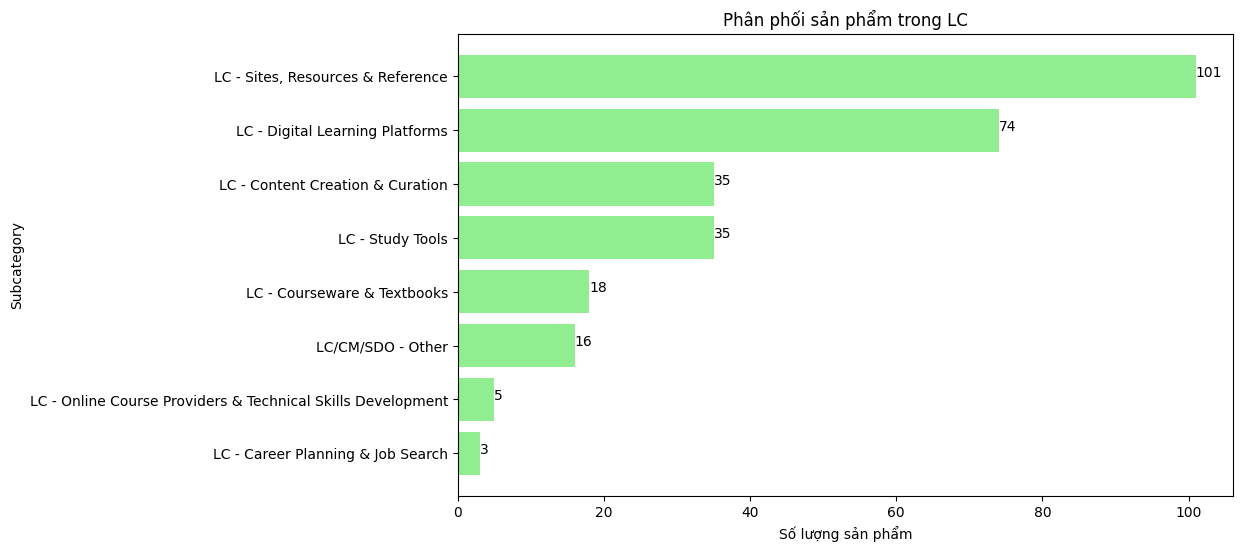

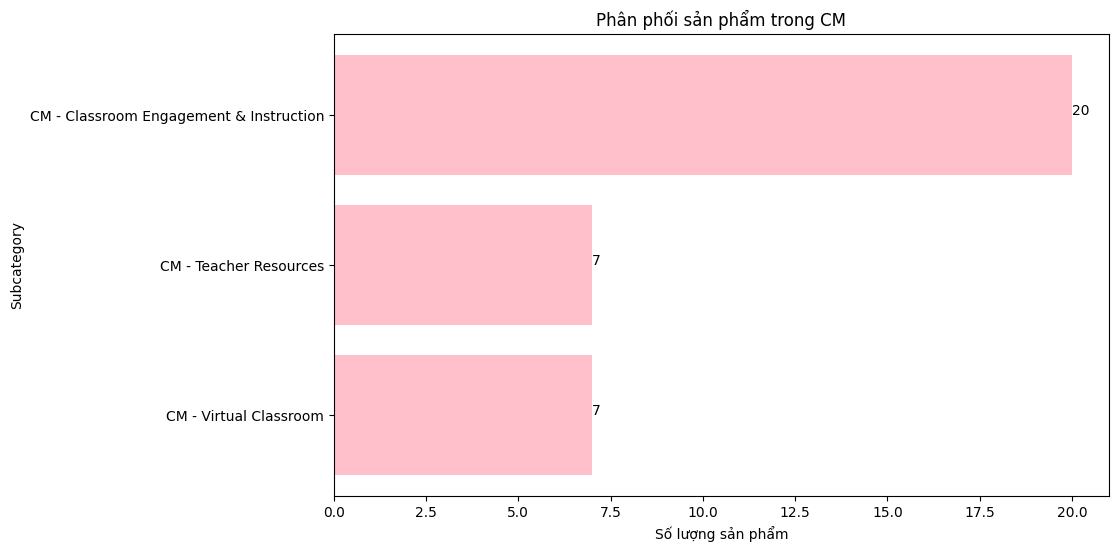

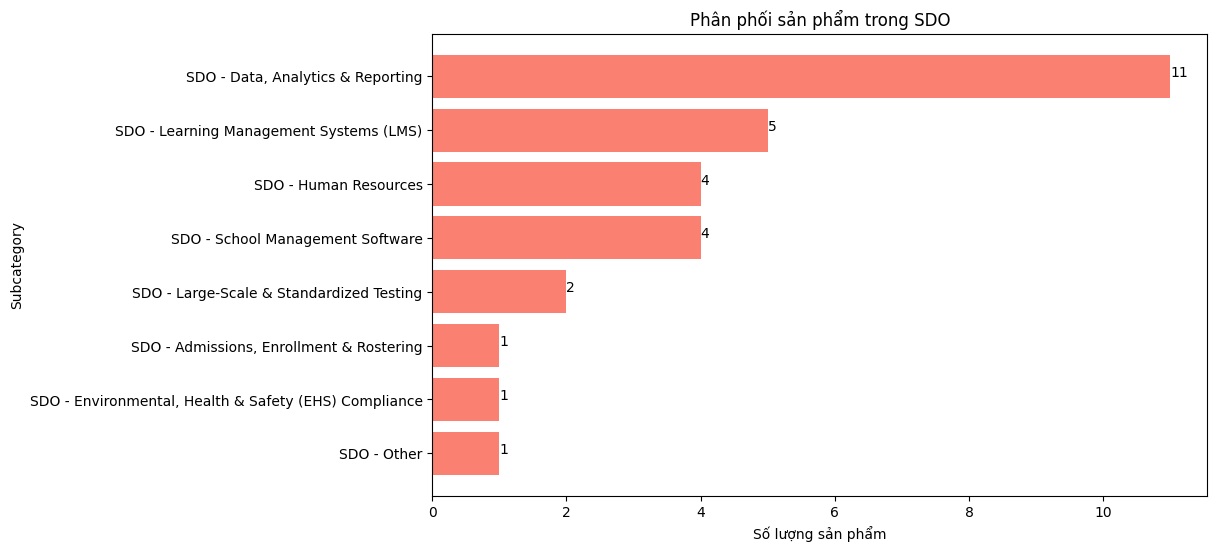

In [57]:
# Tạo hàm
def plot_data(data, title, color):
    # Sắp xếp dữ liệu từ cao đến thấp
    sorted_data = data.sort_values(by='Counts', ascending=False)

    # Tạo biểu đồ
    plt.figure(figsize=(10, 6))
    plt.barh(sorted_data['Consolidated Subcategory'], sorted_data['Counts'], color=color)
    for index, value in enumerate(sorted_data['Counts']):
        plt.text(value, index, str(value))
    plt.xlabel('Số lượng sản phẩm')
    plt.ylabel('Subcategory')
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.show()


# Chỉ lấy dữ liệu của LC, CM và SDO
lc_data = gop[gop['Consolidated Subcategory'].str.startswith('LC')]
cm_data = gop[gop['Consolidated Subcategory'].str.startswith('CM')]
sdo_data = gop[gop['Consolidated Subcategory'].str.startswith('SDO')]
# Vẽ biểu đồ
plot_data(lc_data, 'Phân phối sản phẩm trong LC', 'lightgreen')
plot_data(cm_data, 'Phân phối sản phẩm trong CM', 'pink')
plot_data(sdo_data, 'Phân phối sản phẩm trong SDO', 'salmon')

### Nhận xét
- **Đa dạng sản phẩm**: Có sự đa dạng lớn về loại sản phẩm, từ nội dung học thuật đến quản lý lớp học và hoạt động của trường học. -> Cho thấy sự phong phú và đa dạng của nguồn tài nguyên học tập và công cụ hỗ trợ giáo dục tại Hoa Kỳ.
- **LC chiếm ưu thế**: Phân khúc Learning & Curriculum (LC) có số lượng sản phẩm nhiều nhất, cho thấy nhu cầu cao về nguồn học liệu và nền tảng học trực tuyến (như tài liệu giảng dạy, sách giáo trình, khóa học trực tuyến...).
- **Classroom Management (CM) và School & District Operations (SDO)** Cả hai nhóm này cũng có mặt với các sản phẩm hỗ trợ giảng dạy và quản lý trường học cùng số lượng khá phong phú  -> Cho thấy sự đa dạng trong việc hỗ trợ quản lý và vận hành trường học.
- **Sản phẩm đa năng**: Một số sản phẩm có thể áp dụng cho cả ba lĩnh vực (LC/CM/SDO), phản ánh sự linh hoạt và khả năng tích hợp trong môi trường giáo dục.-> Giúp tối ưu hóa việc quản lý lớp học, cung cấp tài liệu học tập và hỗ trợ hoạt động của trường học

**=>** **Sự phân bố các sản phẩm trong nhóm sản phẩm thể hiện sự đa dạng và sự phong phú của hệ thống giáo dục và công nghệ hỗ trợ tại Hoa Kỳ.**

 **1.2 Mức tương tác theo sản phẩm của Hoa Kì năm 2020**

In [58]:
engagement_df1= engagement_df1.dropna() #Loại bỏ NaN
engagement_df1

,district_id,time,lp_id,pct_access,engagement_index
1,1000,2020-01-01,17941.0,0.03,0.90
2,1000,2020-01-01,65358.0,0.03,1.20
3,1000,2020-01-01,98265.0,0.57,37.79
5,1000,2020-01-01,90153.0,0.06,3.90
7,1000,2020-01-01,29322.0,0.06,5.10
...,...,...,...,...,...
22324183,9927,2020-12-31,57371.0,0.04,3.94
22324185,9927,2020-12-31,56028.0,0.02,0.20
22324186,9927,2020-12-31,14124.0,0.02,0.99
22324188,9927,2020-12-31,13496.0,0.12,6.51


In [59]:
# Nối engagement_df và product_df dựa trên cột 'lp_id'
merged_df = pd.merge(engagement_df1, product_df, on='lp_id', how='left')

In [60]:
import pandas as pd
import plotly.express as px

# Tạo DataFrame
data = merged_df[['primary_essential_function', 'provider/company_name', 'product_name']]
data = data.dropna()  # Loại bỏ các hàng có giá trị NaN

# Tách 'primary_essential_function' để lấy ký hiệu loại sản phẩm (LC/CM/SDO)
data['Symbol'] = data['primary_essential_function'].apply(lambda x: x.split(' - ')[0])

# Thêm cột 'engagement_index' từ DataFrame gốc
data['engagement_index'] = merged_df['engagement_index']

# Nhóm dữ liệu và tính trung bình 'engagement_index'
grouped_data = data.groupby(['primary_essential_function', 'provider/company_name', 'product_name', 'Symbol'], as_index=False).mean()

# Sắp xếp dữ liệu theo 'engagement_index' và lấy 15 sản phẩm có chỉ số tương tác cao nhất
top_products = grouped_data.sort_values('engagement_index', ascending=False).head(15)

# Vẽ biểu đồ cột cho 15 sản phẩm trên
fig = px.bar(top_products, x='product_name', y='engagement_index',color='product_name', title='Mức độ tương tác theo sản phẩm - 2020')

# Cập nhật layout cho biểu đồ
fig.update_layout(
    template='plotly_white',
    xaxis_tickangle=45,
    showlegend=False
)

# In biểu đồ
fig.show()


### Nhận xét
- **Google Docs**: Đứng đầu với chỉ số tương tác cao nhất, cho thấy sự phổ biến rộng rãi của nó trong việc soạn thảo và chia sẻ tài liệu trực tuyến.
- **Các sản phẩm khác**: Bao gồm cả các nền tảng học tập và công cụ hỗ trợ giáo dục khác, phản ánh sự đa dạng trong việc sử dụng công nghệ để hỗ trợ học tập và làm việc.
- **Sự chênh lệch**: Có sự chênh lệch rõ rệt về mức độ tương tác giữa các sản phẩm, với Google Docs chiếm ưu thế đáng kể so với các sản phẩm khác.

- **Điều thú vị là Zoom và Meet** đều xuất hiện trong danh sách, mặc dù Zoom đã được tạo ra cách đây gần một thập kỷ (phát hành vào năm 2012) nhưng hầu như không được đại đa số sinh viên và những người không phải sinh viên biết đến trước năm 2020, trong khi Meet có mức sử dụng thấp hơn nhiều và một số tính năng dành riêng cho tài khoản doanh nghiệp cho đến khi Covid bùng nổ.

**=> Cho thấy cái nhìn tổng quan về xu hướng sử dụng công nghệ trong giáo dục và làm việc, đặc biệt là trong bối cảnh năm 2020 khi đại dịch COVID-19 thúc đẩy nhu cầu học tập và làm việc từ xa.**

## Sự phổ biến của các sản phẩm này có thể được giải thích bởi một số yếu tố:

- Các sản phẩm này đều dễ sử dụng và có thể truy cập từ mọi thiết bị.
- Các sản phẩm này cung cấp các tính năng hữu ích cho giáo viên và học sinh.
- Các sản phẩm này được nhiều trường học và khu học chính sử dụng.

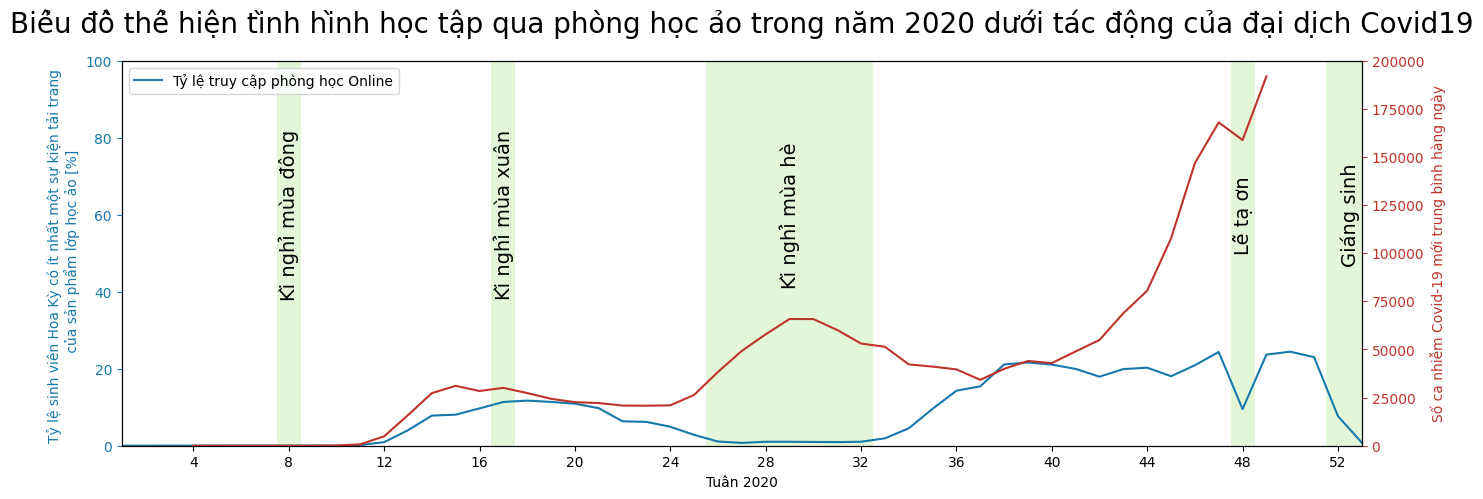

In [77]:
# Sử dụng data us_covid
us_covid = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/us_covid19_daily.csv")
# Chuyen doi du lieu date sang nam- thang- ngay
us_covid['date'] = pd.to_datetime(us_covid.date, format = '%Y%m%d')
# Them cot tuan
us_covid['cw'] = pd.DatetimeIndex(us_covid['date']).week
# sap xep du lieu theo tang dan cot date
us_covid = us_covid.sort_values(by='date')
# Tinh ca nhien theo tuan
us_covid['new_cases'] = us_covid['positive'].diff()
# Tính trung bình số ca nhiễm mới theo tuần
us_covid = us_covid.groupby('cw')[['new_cases']].mean().reset_index(drop=False)
#Lọc sản phẩm học trực tuyến(xác định các sản phẩm có chức năng phụ là "Virtual Classroom" từ product_df)
virtual_classroom_lp_id = product_df[product_df.SubCategory == 'Virtual Classroom'].lp_id.unique()
#  Tính tổng "pct_access" theo tuần và quận
engagement_sum = engagement_cw[engagement_cw.lp_id.isin(virtual_classroom_lp_id)].groupby(['cw', 'district_id']).pct_access.sum().to_frame().reset_index()
# Tạo hình f và trục ax
f, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 5))
# Tính TB tỷ lệ truy cập theo tuần dựa trên pct_access
temp = engagement_sum.groupby('cw').pct_access.mean().to_frame().reset_index(drop=False)
# Biểu đồ tỷ lệ truy cập (trục chính)
sns.lineplot(data=temp, x='cw', y='pct_access', label=f'Tỷ lệ truy cập phòng học Online', color='#1679AB')
# Thiết lập giới hạn trục y (0-100%) và trục x (tuần 1-53).
ax.set_ylim([0, 100])
ax.set_xlim([1, 53])
# Biểu đồ số ca Covid mới (trục phụ)
ax2 = ax.twinx()
sns.lineplot(x=us_covid.cw, y=us_covid.new_cases, ax=ax2, label = f'Trung bình tỷ lệ mắc Covid mới', color='#BF342A', legend =False)
ax2.set_ylim([0, 200000])

#Đánh dấu kì học
ax.add_patch(Rectangle((7.5, 0), 1, 100, fill=True, alpha=0.2, color='#76d33c', lw=0))
ax.annotate('Kì nghỉ mùa đông', xy=(8, 60), fontsize=14, color='black', rotation=90, va='center', ha='center')

ax.add_patch(Rectangle((16.5, 0), 1, 100, fill=True, alpha=0.2, color='#76d33c', lw=0))
ax.annotate('Kì nghỉ mùa xuân', xy=(17, 60), fontsize=14, color='black', rotation=90, va='center', ha='center')

ax.add_patch(Rectangle((25.5, 0), 7, 100, fill=True, alpha=0.2, color='#76d33c', lw=0))
ax.annotate('Kì nghỉ mùa hè', xy=(29, 60), fontsize=14, color='black', rotation=90, va='center', ha='center')

ax.add_patch(Rectangle((47.5, 0), 1, 100, fill=True, alpha=0.2, color='#76d33c', lw=0))
ax.annotate('Lễ tạ ơn', xy=(48, 60), fontsize=14, color='black', rotation=90, va='center', ha='center')

ax.add_patch(Rectangle((51.5, 0), 3, 100, fill=True, alpha=0.2, color='#76d33c', lw=0))
ax.annotate('Giáng sinh', xy=(52.5, 60), fontsize=14, color='black', rotation=90, va='center', ha='center')

ax.set_xlabel('Tuần 2020')
ax.xaxis.set_major_locator(MultipleLocator(4))
ax.set_ylabel('Tỷ lệ sinh viên Hoa Kỳ có ít nhất một sự kiện tải trang \n của sản phẩm lớp học ảo [%]', color='#1679AB')
ax.tick_params(axis='y', colors = '#1679AB')

ax2.set_ylabel('Số ca nhiễm Covid-19 mới trung bình hàng ngày', color='#BF342A')
ax2.tick_params(axis='y', colors = '#BF342A')
plt.title('Biểu đồ thể hiện tình hình học tập qua phòng học ảo trong năm 2020 dưới tác động của đại dịch Covid19', size=20, family="Verdana", pad=20)
plt.show()

### Nhận xét
- Có thể thấy phần lớn sự tương tác giữa con người với nhau bị mất đi trong thời gian đại dịch, việc tạo cơ hội cho học sinh tham gia vào các lớp học ảo đã giúp họ tương tác với giáo viên và bạn bè của mình. Do đó, việc sử dụng sản phẩm lớp học ảo có thể là một dấu hiệu cho thấy trải nghiệm giáo dục tốt.

- Tuy nhiên, chúng ta cũng có thể thấy rằng chỉ có khoảng 20% học sinh Hoa Kỳ sử dụng sản phẩm lớp học ảo hàng ngày trong năm học 2019-2020 sau khi dịch COVID-19 bùng phát và con số này chỉ tăng nhẹ lên khoảng 30% trong năm học 2020-2021 . Điều đó cho thấy phần lớn sinh viên Mỹ không có cơ hội tham gia lớp học ảo.


In [64]:
engage_avg_perday = engagement_df.groupby(["time"], as_index=False).agg(np.mean)
engage_avg_perday.rename(columns={"time": "Date"}, inplace=True)

fig = px.line(data_frame=engage_avg_perday, x="Date", y="engagement_index",
              title="Tổng số lượng tương tác với sản phẩm mỗi ngày - 2020")

fig.update_xaxes(rangeslider_visible=True)
fig.update_yaxes(gridcolor="lightgray")

fig.add_vline(x=datetime.datetime(2020,2,9).timestamp() * 1000,
             annotation_text="Trường học đóng cửa",opacity=0.50,
             annotation_position="top right", line_dash="dash")
fig.add_vrect(x0="2020-04-09", x1="2020-04-13",
              annotation_text="Kì nghỉ mùa xuân", annotation_position="top left",
              annotation=dict(font_size=14, font_family="Verdana"),
              fillcolor="#76d33c", opacity=0.25, line_width=0)
fig.add_vrect(x0="2020-06-08", x1="2020-08-20",
              annotation_text="Kì nghỉ mùa hè", annotation_position="top left",
              annotation=dict(font_size=14, font_family="Verdana"),
              fillcolor="#76d33c", opacity=0.25, line_width=0)
fig.add_vrect(x0="2020-11-25", x1="2020-11-29",
              annotation_text="Lễ tạ ơn", annotation_position="top left",
              annotation=dict(font_size=14, font_family="Verdana"),
              fillcolor="#76d33c", opacity=0.25, line_width=0)
fig.add_vrect(x0="2020-12-21", x1="2020-12-31",
              annotation_text="Giáng sinh", annotation_position="top left",
              annotation=dict(font_size=14, font_family="Verdana"),
              fillcolor="#76d33c", opacity=0.25, line_width=0)

del engage_avg_perday
gc.collect()
fig.show()

## Nhận xét biểu đồ trên mô tả hai năm học. 2019-2020, 2020-2021
- Đường nét đứt cách điệu được tô đậm cho biết khoảng thời gian trung bình khi các trường học bắt đầu đóng cửa do đại dịch. Hầu hết các trường công đã đóng cửa vào ngày 18 tháng 3 năm học 2019-2020.
- Trước khi đóng cửa: Sự tham gia vào công nghệ giáo dục ít hơn so với các thời điểm khác trong năm nhưng không phải không có, cho thấy một số lượng đáng kể học sinh đã quen thuộc với Edu Yech trước khi các trường bắt đầu giáo dục trực tuyến và đã sử dụng nó.
* Biến động trong biểu đồ
- Các lần giảm tải trang liên tiếp trên biểu đồ cho thấy các ngày cuối tuần và ngày lễ kéo dài một hoặc hai ngày.
- Các sự kiện tải trang cao hơn sau kỳ nghỉ hè ngay cả vào cuối tuần (tức là trong học kỳ đầu tiên và thứ hai của năm học 20-21) so với học kỳ thứ ba và thứ tư (của năm học 19-20).

In [65]:
# Merge all dataframes
data_df = engagement_cw.merge(product_df[['lp_id', 'product_name', 'Category', 'SubCategory']], on='lp_id')
data_df = data_df.merge(district_df, on='district_id')

In [66]:
data_df.head()

,cw,lp_id,district_id,pct_access,engagement_index,covid_phase,product_name,Category,SubCategory,state,locale,pct_black/hispanic,pct_free/reduced,county_connections_ratio,pp_total_raw
0,1,10533.0,1000,0.138000,48.810,1,Scholastic,LC,"Sites, Resources & References",Connecticut,Suburb,0.7,0.3,"[0.18, 1[",NaN
1,2,10533.0,1000,0.461429,66.932,1,Scholastic,LC,"Sites, Resources & References",Connecticut,Suburb,0.7,0.3,"[0.18, 1[",NaN
2,3,10533.0,1000,0.155000,10.554,1,Scholastic,LC,"Sites, Resources & References",Connecticut,Suburb,0.7,0.3,"[0.18, 1[",NaN
3,4,10533.0,1000,0.100000,15.090,1,Scholastic,LC,"Sites, Resources & References",Connecticut,Suburb,0.7,0.3,"[0.18, 1[",NaN
4,5,10533.0,1000,0.242857,31.300,1,Scholastic,LC,"Sites, Resources & References",Connecticut,Suburb,0.7,0.3,"[0.18, 1[",NaN


In [67]:
mapping_dict = {'[0, 0.2[':0.1,
                '[0.2, 0.4[':0.3,
                '[0.4, 0.6[':0.5,
                '[0.6, 0.8[':0.7,
                '[0.8, 1[':0.9,
                np.nan:np.nan}
districts_info['pct_black/hispanic'] = districts_info['pct_black/hispanic'].map(mapping_dict)
districts_info['pct_free/reduced'] = districts_info['pct_free/reduced'].map(mapping_dict)
# Replace state strings with abbreviations
us_state_abbrev = {
    'Alabama': 'AL',
    'Alaska': 'AK',
    'American Samoa': 'AS',
    'Arizona': 'AZ',
    'Arkansas': 'AR',
    'California': 'CA',
    'Colorado': 'CO',
    'Connecticut': 'CT',
    'Delaware': 'DE',
    'District Of Columbia': 'DC',
    'District of Columbia': 'DC',
    'Florida': 'FL',
    'Georgia': 'GA',
    'Guam': 'GU',
    'Hawaii': 'HI',
    'Idaho': 'ID',
    'Illinois': 'IL',
    'Indiana': 'IN',
    'Iowa': 'IA',
    'Kansas': 'KS',
    'Kentucky': 'KY',
    'Louisiana': 'LA',
    'Maine': 'ME',
    'Maryland': 'MD',
    'Massachusetts': 'MA',
    'Michigan': 'MI',
    'Minnesota': 'MN',
    'Mississippi': 'MS',
    'Missouri': 'MO',
    'Montana': 'MT',
    'Nebraska': 'NE',
    'Nevada': 'NV',
    'New Hampshire': 'NH',
    'New Jersey': 'NJ',
    'New Mexico': 'NM',
    'New York': 'NY',
    'North Carolina': 'NC',
    'North Dakota': 'ND',
    'Northern Mariana Islands':'MP',
    'Ohio': 'OH',
    'Oklahoma': 'OK',
    'Oregon': 'OR',
    'Pennsylvania': 'PA',
    'Puerto Rico': 'PR',
    'Rhode Island': 'RI',
    'South Carolina': 'SC',
    'South Dakota': 'SD',
    'Tennessee': 'TN',
    'Texas': 'TX',
    'Utah': 'UT',
    'Vermont': 'VT',
    'Virgin Islands': 'VI',
    'Virginia': 'VA',
    'Washington': 'WA',
    'West Virginia': 'WV',
    'Wisconsin': 'WI',
    'Wyoming': 'WY'
}

districts_info['state'] = districts_info['state'].replace(us_state_abbrev)

In [70]:
us_states = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/COVID19_state.csv")
us_states['State'] = us_states['State'].replace(us_state_abbrev)
us_states = us_states[['State', 'Gini', 'Income', 'GDP']]
us_states.columns = ['state', 'gini', 'income', 'gdp']

# Broadband access
broadband_access = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/broadband_access.csv")
broadband_access = broadband_access[['state_abr', 'no_comp', 'no_internet']]
broadband_access = broadband_access.groupby('state_abr').mean().reset_index(drop=False)
broadband_access.columns = ['state', 'no_comp', 'no_internet']

# Ethnicity
demographic_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/acs2017_county_data.csv")
demographic_data = demographic_data[['State', 'Hispanic', 'Black']]
demographic_data['State'] = demographic_data['State'].replace(us_state_abbrev)
demographic_data = demographic_data.groupby('State').mean().reset_index(drop=False)
demographic_data.columns = ['state', 'Hispanic', 'Black']
demographic_data['pct_black/hispanic_state'] = demographic_data['Hispanic'] + demographic_data['Black']

In [71]:
districts_info = districts_info.merge(us_states, on='state')
districts_info = districts_info.merge(broadband_access, on='state')
districts_info = districts_info.merge(demographic_data, on='state')

districts_info = districts_info[['district_id', 'state',
                   'pct_black/hispanic', 'pct_black/hispanic_state',
                   'gini', 'income', 'gdp',
                   'no_comp', 'no_internet']]

In [72]:
corrmat = districts_info[['state','pct_black/hispanic', 'pct_black/hispanic_state',
                   'gini', 'income', 'gdp',
                   'no_comp', 'no_internet']].corr()

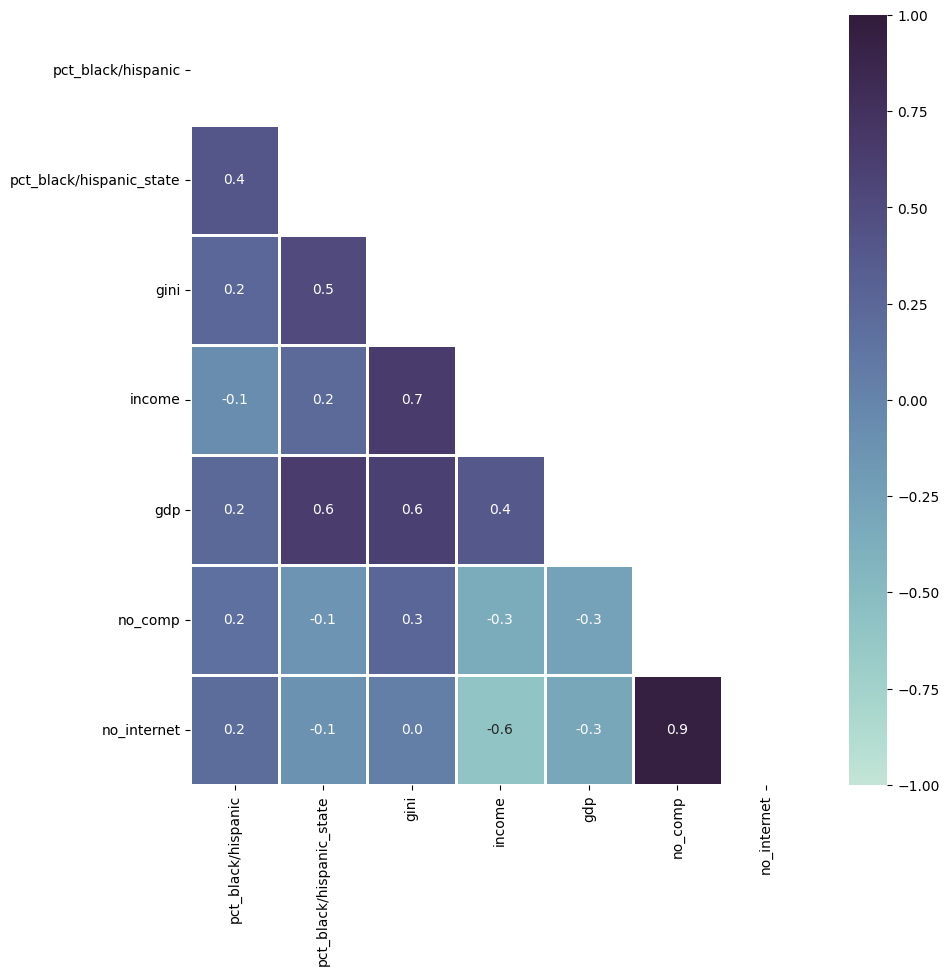

In [73]:
f, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 10))  # Create the figure and axis

sns.heatmap(corrmat, annot=True, mask=np.triu(corrmat), vmin=-1, vmax=1, linewidths=1, cmap=sns.cubehelix_palette(start=.5, rot=-.5, as_cmap=True), fmt=".1f")  # Corrected formatting

plt.show()

# Nhận xét
- Hình ảnh headmap cho thấy mối tương quan giữa tỷ lệ người da đen và người gốc Tây Ban Nha (pct_black/hispanic) với các yếu tố khác như tỷ lệ người da đen và người gốc Tây Ban Nha ở cấp tiểu bang (pct_black/hispanic_state), chỉ số Gini (gini), thu nhập (income), tỷ lệ người không có máy tính (no_comp), và tỷ lệ người không có internet (no_internet).

# Mối tương quan giữa pct_black/hispanic và các yếu tố khác:

- pct_black/hispanic_state: Mối tương quan giữa pct_black/hispanic và pct_black/hispanic_state là dương và mạnh. Điều này cho thấy rằng tỷ lệ người da đen và người gốc Tây Ban Nha ở một khu vực có xu hướng cao hơn khi tỷ lệ người da đen và người gốc Tây Ban Nha ở cấp tiểu bang cao hơn.
- gini(Mức độ giàu có): Mối tương quan giữa pct_black/hispanic và gini là dương và mạnh. Điều này cho thấy rằng tỷ lệ người da đen và người gốc Tây Ban Nha có xu hướng cao hơn ở những khu vực có mức độ bất bình đẳng thu nhập cao hơn.
- income: Mối tương quan giữa pct_black/hispanic và income là âm và mạnh. Điều này cho thấy rằng tỷ lệ người da đen và người gốc Tây Ban Nha có xu hướng thấp hơn ở những khu vực có thu nhập trung bình cao hơn.
- no_comp: Mối tương quan giữa pct_black/hispanic và no_comp là âm và mạnh. Điều này cho thấy rằng tỷ lệ người da đen và người gốc Tây Ban Nha có xu hướng thấp hơn ở những khu vực có tỷ lệ người không có máy tính cao hơn.
- no_internet: Mối tương quan giữa pct_black/hispanic và no_internet là âm và mạnh. Điều này cho thấy rằng tỷ lệ người da đen và người gốc Tây Ban Nha có xu hướng thấp hơn ở những khu vực có tỷ lệ người không có internet cao hơn.
# Kết luận:
- Cho thấy rằng tỷ lệ người da đen và người gốc Tây Ban Nha có mối tương quan với một số yếu tố khác, bao gồm tỷ lệ người da đen và người gốc Tây Ban Nha ở cấp tiểu bang, chỉ số Gini, thu nhập, tỷ lệ người không có máy tính, và tỷ lệ người không có internet. Mối tương quan giữa pct_black/hispanic và các yếu tố này có thể được giải thích bởi một số yếu tố, chẳng hạn như phân biệt đối xử, phân biệt, và cơ hội kinh tế.
# Mục đích
- Xác định các khu vực có tỷ lệ người da đen và người gốc Tây Ban Nha cao.
- Phát triển các chương trình và chính sách nhắm mục tiêu đến các cộng đồng người da đen và người gốc Tây Ban Nha.
- Theo dõi tiến trình của các chương trình và chính sách này.

#**2. Đại dịch COVID-19 có ảnh hưởng gì đến việc học trực tuyến và từ xa**

In [ ]:
df3= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/districts_info.csv')
df3[df3['pp_total_raw'] == '[4000, 6000[']
# df3_1.value_counts()

,district_id,state,locale,pct_black/hispanic,pct_free/reduced,county_connections_ratio,pp_total_raw
85,7308,Utah,Suburb,"[0, 0.2[","[0.2, 0.4[","[0.18, 1[","[4000, 6000["
148,6762,Utah,Suburb,"[0, 0.2[","[0, 0.2[","[0.18, 1[","[4000, 6000["


In [ ]:
df3['pp_total_raw'].value_counts()

pp_total_raw
[8000, 10000[     30
[10000, 12000[    17
[14000, 16000[    15
[12000, 14000[    15
[6000, 8000[      13
[16000, 18000[    13
[18000, 20000[     8
[20000, 22000[     2
[22000, 24000[     2
[4000, 6000[       2
[32000, 34000[     1
Name: count, dtype: int64

In [ ]:
df3[df3['pp_total_raw'] == '[4000, 6000[']
#Bang có tỷ lệ đầu tư công cho mỗi học sinh thấp nhất=> Utah

,district_id,state,locale,pct_black/hispanic,pct_free/reduced,county_connections_ratio,pp_total_raw
85,7308,Utah,Suburb,"[0, 0.2[","[0.2, 0.4[","[0.18, 1[","[4000, 6000["
148,6762,Utah,Suburb,"[0, 0.2[","[0, 0.2[","[0.18, 1[","[4000, 6000["


In [ ]:
ny =df3[df3['state'] == "New York"]
ny
#Bang có tỷ lệ đầu tư công cho mỗi học sinh cao nhất=> New York

,district_id,state,locale,pct_black/hispanic,pct_free/reduced,county_connections_ratio,pp_total_raw
14,2257,New York,Rural,"[0, 0.2[","[0.2, 0.4[",NaN,"[20000, 22000["
51,7798,New York,Rural,"[0, 0.2[","[0.2, 0.4[","[0.18, 1[","[22000, 24000["
77,2940,New York,Suburb,"[0, 0.2[","[0.2, 0.4[",NaN,"[14000, 16000["
121,8520,New York,Rural,"[0, 0.2[","[0.2, 0.4[","[0.18, 1[","[16000, 18000["
124,4775,New York,Suburb,"[0, 0.2[","[0.2, 0.4[","[0.18, 1[","[16000, 18000["
128,1470,New York,Rural,"[0, 0.2[","[0.4, 0.6[","[0.18, 1[","[32000, 34000["
218,9536,New York,City,"[0.8, 1[","[0.8, 1[","[0.18, 1[",NaN
228,9515,New York,Rural,"[0, 0.2[","[0.4, 0.6[","[0.18, 1[","[18000, 20000["


In [ ]:
te =df3[df3['state'] == "Utah"]
te

,district_id,state,locale,pct_black/hispanic,pct_free/reduced,county_connections_ratio,pp_total_raw
2,4921,Utah,Suburb,"[0, 0.2[","[0.2, 0.4[","[0.18, 1[","[6000, 8000["
6,3710,Utah,Suburb,"[0, 0.2[","[0.4, 0.6[","[0.18, 1[","[6000, 8000["
8,9812,Utah,Suburb,"[0, 0.2[","[0.2, 0.4[","[0.18, 1[","[6000, 8000["
15,7614,Utah,City,"[0.2, 0.4[","[0.2, 0.4[","[0.18, 1[","[8000, 10000["
21,8328,Utah,Town,"[0, 0.2[","[0.4, 0.6[","[0.18, 1[","[10000, 12000["
36,4936,Utah,Suburb,"[0, 0.2[","[0, 0.2[","[0.18, 1[","[6000, 8000["
41,5231,Utah,Town,"[0, 0.2[","[0.4, 0.6[","[0.18, 1[","[10000, 12000["
45,2165,Utah,Suburb,"[0.2, 0.4[","[0.2, 0.4[","[0.18, 1[","[6000, 8000["
55,7660,Utah,Suburb,"[0, 0.2[","[0, 0.2[","[0.18, 1[","[6000, 8000["
66,1772,Utah,City,"[0.2, 0.4[","[0.4, 0.6[","[0.18, 1[","[8000, 10000["


In [ ]:
dt= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/engagement_data.csv')
dt
#biến đọc dữ liệu từ file engagement_data.csv

,district_id,time,lp_id,pct_access,engagement_index
0,1000,2020-01-01,93690.0,0.00,NaN
1,1000,2020-01-01,17941.0,0.03,0.90
2,1000,2020-01-01,65358.0,0.03,1.20
3,1000,2020-01-01,98265.0,0.57,37.79
4,1000,2020-01-01,59257.0,0.00,NaN
...,...,...,...,...,...
22324185,9927,2020-12-31,56028.0,0.02,0.20
22324186,9927,2020-12-31,14124.0,0.02,0.99
22324187,9927,2020-12-31,98001.0,0.00,NaN
22324188,9927,2020-12-31,13496.0,0.12,6.51


In [ ]:
tn = dt[(dt['district_id'] == 7308) | (dt['district_id'] == 6762)]
tn['lp_id'].value_counts()
#biến lấy ra dữ liệu từ bang Utah từ district_id

lp_id
99916.0    732
95731.0    732
28504.0    728
47364.0    726
72758.0    721
          ... 
51439.0      1
73213.0      1
30438.0      1
31834.0      1
50114.0      1
Name: count, Length: 2081, dtype: int64

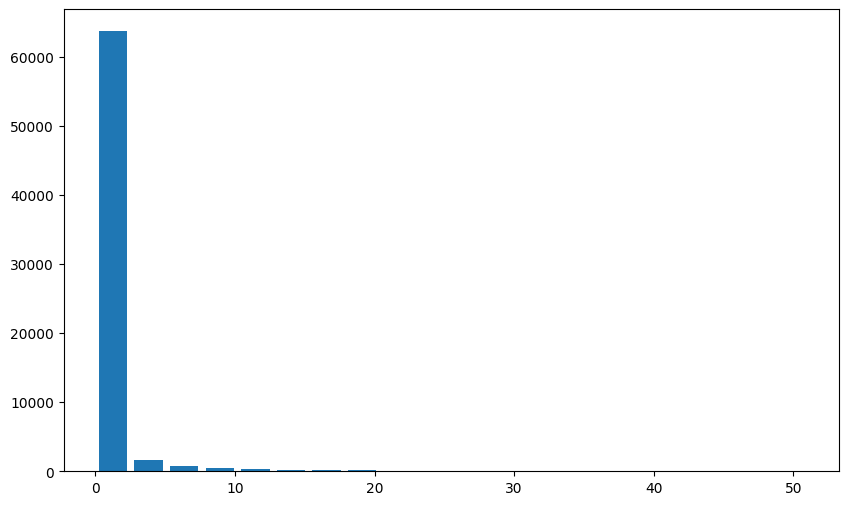

In [ ]:
plt.hist(tn['pct_access'], bins= 20, rwidth= 0.8)
# plt.xlable('Percantage')
# plt.ylable('Count')
plt.show()
# Vẽ biểu đồ cột để xem Outliners

In [ ]:
tn['pct_access'].mean()
# Lấy ra trung bình của biến pct_access của bang Tennessee

0.8730312784784077

In [ ]:
tn['pct_access'].std()
# Lấy ra độ lệch chuẩn của biến pct_access của bang Tennessee

3.638666843328803

In [ ]:
uper= tn['pct_access'].mean() + 3*tn['pct_access'].std() #Cận dưới của biến pct_access của bang Tennessee
uper2= tn['engagement_index'].mean() + 3*tn['engagement_index'].std() #Cận dưới của biến engagement_index của bang Tennessee
# Công thức tính cận trên cận dưới để loại bỏ Outliners bằng Z-score Scaling

In [ ]:
lower=tn['pct_access'].mean() - 3*tn['pct_access'].std()#Cận trên của biến pct_access của bang Tennessee
lower2= tn['engagement_index'].mean() - 3*tn['engagement_index'].std()#Cận trên của biến engagement_index của bang Tennessee

In [ ]:
tn[(tn['engagement_index'] > uper2) | (tn['engagement_index'] < lower2)]#Lọc ra các outliners của biến engagement_index

,district_id,time,lp_id,pct_access,engagement_index
15096502,6762,2020-01-14,26488.0,7.90,5313.93
15097321,6762,2020-01-24,24711.0,16.39,11398.34
15097696,6762,2020-01-29,24711.0,8.92,11730.29
15098694,6762,2020-02-10,26488.0,14.52,5871.37
15098937,6762,2020-02-13,24711.0,4.36,9703.32
...,...,...,...,...,...
16083432,7308,2020-12-03,47364.0,17.61,5968.81
16084124,7308,2020-12-08,47364.0,16.70,5348.42
16084199,7308,2020-12-09,47364.0,17.30,5644.20
16085298,7308,2020-12-15,47364.0,17.06,5745.22


In [ ]:
#Lọc các outliners của biến pct_access
tn[(tn['pct_access'] > uper) | (tn['pct_access'] < lower)]

,district_id,time,lp_id,pct_access,engagement_index
15095811,6762,2020-01-06,95731.0,27.86,2762.99
15095831,6762,2020-01-06,61441.0,19.75,871.10
15095854,6762,2020-01-06,47364.0,29.31,4120.58
15095857,6762,2020-01-06,99916.0,24.53,1160.08
15095885,6762,2020-01-07,99916.0,25.99,1103.95
...,...,...,...,...,...
16085298,7308,2020-12-15,47364.0,17.06,5745.22
16085335,7308,2020-12-16,76649.0,14.34,794.24
16085456,7308,2020-12-16,47364.0,15.68,5308.98
16085553,7308,2020-12-17,76649.0,13.47,764.08


In [ ]:
tn_new= tn[(tn['pct_access'] < uper) & (tn['pct_access'] > lower)] #tập dữ liệu mới sau khi đã loại bỏ các Outliners của biến pct_access
tn_new2= tn[(tn['engagement_index'] <uper2) & (tn['engagement_index'] >lower2)] #tập dữ liệu mới sau khi đã loại bỏ các Outliners của biến engagement_index

In [ ]:
tn_new= tn_new.dropna() #Loại bỏ dữ liệu NaN
tn_new

,district_id,time,lp_id,pct_access,engagement_index
15095671,6762,2020-01-01,99916.0,0.21,10.40
15095672,6762,2020-01-01,95731.0,0.21,16.63
15095673,6762,2020-01-01,47364.0,0.42,70.69
15095674,6762,2020-01-01,50479.0,0.21,4.16
15095675,6762,2020-01-01,57084.0,0.21,2.08
...,...,...,...,...,...
16086413,7308,2020-12-31,48333.0,0.03,1.01
16086416,7308,2020-12-31,35007.0,0.10,26.47
16086417,7308,2020-12-31,64948.0,0.03,2.35
16086418,7308,2020-12-31,94984.0,0.03,0.67


In [ ]:
print(tn.shape)
print(tn_new.shape)
#Xem kích thước của tập dữ liệu đã thay đổi như thế nào sau khi loại bỏ các dữ liệu nan

(68034, 5)
(41156, 5)



 **DỮ LIỆU CỦA BANG Tennessee**

In [ ]:
m1= tn_new[tn_new['time'].str.contains('2020-01-')] #Lọc ra dữ liệu của tháng 1
m1.dropna()
m1_1= tn_new2[tn_new2['time'].str.contains('2020-01-')]
m1_1.dropna()
jan2= m1['pct_access'].mean() #Tính giá trị trung bình của biến pct_access của tháng 1 sau khi dã loại bỏ nan và Outliners
jan3 = m1_1['engagement_index'].mean() #Tính giá trị trung bình của biến engagement_index của tháng 1 sau khi dã loại bỏ nan và Outliners

In [ ]:
m2= tn_new[tn_new['time'].str.contains('2020-02-')]#Lọc ra dữ liệu của tháng 2
m2.dropna()
m2_1= tn_new2[tn_new2['time'].str.contains('2020-02-')]
m2_1.dropna()
feb2= m2['pct_access'].mean()#Tính giá trị trung bình của biến pct_access của tháng 2 sau khi dã loại bỏ nan và Outliners
feb3 = m2_1['engagement_index'].mean()#Tính giá trị trung bình của biến pct_access của tháng 2 sau khi dã loại bỏ nan và Outliners

In [ ]:
m3= tn_new[tn_new['time'].str.contains('2020-03-')]
m3.dropna()
m3_1= tn_new2[tn_new2['time'].str.contains('2020-03-')]
m3_1.dropna()
mar2= m3['pct_access'].mean()#Tính giá trị trung bình của biến pct_access của tháng 3 sau khi dã loại bỏ nan và Outliners
mar3 = m3_1['engagement_index'].mean()#Tính giá trị trung bình của biến engagement_index của tháng 3 sau khi dã loại bỏ nan và Outliners

In [ ]:
m4= tn_new[tn_new['time'].str.contains('2020-04-')]
m4.dropna()
m4_1= tn_new2[tn_new2['time'].str.contains('2020-04-')]
m4_1.dropna()
apr2= m4['pct_access'].mean()
apr3 = m4_1['engagement_index'].mean()

In [ ]:
m5= tn_new[tn_new['time'].str.contains('2020-05-')]
m5.dropna()
m5_1= tn_new2[tn_new2['time'].str.contains('2020-05-')]
m5_1.dropna()
may2= m5['pct_access'].mean()
may3 = m5_1['engagement_index'].mean()

In [ ]:
m6= tn_new[tn_new['time'].str.contains('2020-06-')]
m6.dropna()
m6_1= tn_new2[tn_new2['time'].str.contains('2020-06-')]
m6_1.dropna()
jun2= m6['pct_access'].mean()
jun3 = m6_1['engagement_index'].mean()

In [ ]:
m7= tn_new[tn_new['time'].str.contains('2020-07-')]
m7.dropna()
m7_1= tn_new2[tn_new2['time'].str.contains('2020-07-')]
m7_1.dropna()
jul2= m7['pct_access'].mean()
jul3 = m7_1['engagement_index'].mean()

In [ ]:
m8= tn_new[tn_new['time'].str.contains('2020-08-')]
m8.dropna()
m8_1= tn_new2[tn_new2['time'].str.contains('2020-08-')]
m8_1.dropna()
agu2= m8['pct_access'].mean()
agu3 = m8_1['engagement_index'].mean()

In [ ]:
m9= tn_new[tn_new['time'].str.contains('2020-09-')]
m9.dropna()
m9_1= tn_new2[tn_new2['time'].str.contains('2020-09-')]
m2_1.dropna()
sep2= m9['pct_access'].mean()
sep3 = m9_1['engagement_index'].mean()

In [ ]:
m10= tn_new[tn_new['time'].str.contains('2020-10-')]
m10.dropna()
m10_1= tn_new2[tn_new2['time'].str.contains('2020-10-')]
m10_1.dropna()
oct2= m10['pct_access'].mean()
oct3 = m10_1['engagement_index'].mean()

In [ ]:
m11= tn_new[tn_new['time'].str.contains('2020-11-')]
m11.dropna()
m11_1= tn_new2[tn_new2['time'].str.contains('2020-11-')]
m11_1.dropna()
nov2= m11['pct_access'].mean()
nov3 = m11_1['engagement_index'].mean()

In [ ]:
m12= tn_new[tn_new['time'].str.contains('2020-12-')]
m12.dropna()
m12_1= tn_new2[tn_new2['time'].str.contains('2020-11-')]
m12_1.dropna()
dec2= m12['pct_access'].mean()
dec3 = m12_1['engagement_index'].mean()

In [ ]:
ny1= dt[(dt['district_id'] == 7798) | (dt['district_id'] == 8520) | (dt['district_id'] == 4775) | (dt['district_id'] == 1470) | (dt['district_id'] == 9515)]
ny1
#Lọc ra chi tiết các biến pct_access và engagement_index của các học khu của New York

,district_id,time,lp_id,pct_access,engagement_index
1020458,1470,2020-01-29,92140.0,0.67,6.65
1020459,1470,2020-01-29,49062.0,0.22,2.22
1020460,1470,2020-01-29,90153.0,0.44,57.65
1020461,1470,2020-01-29,16468.0,1.55,42.13
1020462,1470,2020-01-29,74653.0,10.42,1842.57
...,...,...,...,...,...
21108053,9515,2020-11-24,61441.0,0.12,5.97
21108054,9515,2020-11-24,32213.0,0.12,1.19
21108055,9515,2020-11-24,14769.0,0.12,1.19
21108056,9515,2020-12-08,69827.0,0.12,5.97


In [ ]:
uper3= ny1['pct_access'].mean() + 3*ny1['pct_access'].std()#Cận dưới của biến pct_access sau khi lọc bỏ Outliners
lower3= ny1['pct_access'].mean() - 3*ny1['pct_access'].std()#Cận trên của biến pct_access sau khi lọc bỏ Outliners
uper4= ny1['engagement_index'].mean() + 3*ny1['engagement_index'].std()#Cận dưới của biến engagement_index sau khi lọc bỏ Outliners
lower4= ny1['engagement_index'].mean() - 3*ny1['engagement_index'].std()#Cận trên của biến engagement_index sau khi lọc bỏ Outliners

In [ ]:
ny1[(ny1['pct_access'] > uper3) | (ny1['pct_access'] < lower3)]#Xem các Outliners của biến pct_access

,district_id,time,lp_id,pct_access,engagement_index
1020483,1470,2020-01-29,69827.0,26.39,1181.82
1020494,1470,2020-01-29,57084.0,17.74,725.06
1020498,1470,2020-01-29,95731.0,43.46,3139.69
1020507,1470,2020-01-29,98265.0,17.96,1616.41
1020514,1470,2020-01-29,99916.0,17.96,516.63
...,...,...,...,...,...
21107881,9515,2020-09-22,99916.0,21.62,1940.26
21107895,9515,2020-09-22,61292.0,18.40,2476.70
21107916,9515,2020-09-22,26488.0,24.73,6401.43
21107932,9515,2020-09-22,95731.0,26.64,12464.76


In [ ]:
ny1_new= ny1[(ny1['pct_access'] < uper3) & (ny1['pct_access'] > lower3)]#Tập dữ liệu mới chứa biến pct_access sau khi lọc bỏ Outliners
ny1_new_2= ny1[(ny1['engagement_index'] > lower4) & (ny1['engagement_index'] < uper4)]#Tập dữ liệu mới chứa biến engagement_index sau khi lọc bỏ Outliners

In [ ]:
pct_acc1 = [jan2, feb2, mar2, apr2, may2, jun2, jul2, agu2, sep2, oct2, nov2, dec2]
p1 = pd.DataFrame(pct_acc1)
engage1 = [jan3, feb3, mar3, apr3, may3, jun3, jul3, agu3, sep3, oct3, nov3, dec3]
e1 = pd.DataFrame(engage1)
e1

,0
0,159.569224
1,200.158326
2,170.258193
3,120.154097
4,134.667865
5,19.798979
6,14.395081
7,150.812139
8,165.018605
9,148.617719


In [ ]:
t1= ny1_new[ny1_new['time'].str.contains('2020-01-')]
t1.dropna()
t1_1=  ny1_new_2[ny1_new_2['time'].str.contains('2020-01-')]
t1_1.dropna()
jan= t1['pct_access'].mean()
jan1= t1_1['engagement_index'].mean()

In [ ]:
ny1_new_2

,district_id,time,lp_id,pct_access,engagement_index
1020458,1470,2020-01-29,92140.0,0.67,6.65
1020459,1470,2020-01-29,49062.0,0.22,2.22
1020460,1470,2020-01-29,90153.0,0.44,57.65
1020461,1470,2020-01-29,16468.0,1.55,42.13
1020462,1470,2020-01-29,74653.0,10.42,1842.57
...,...,...,...,...,...
21108053,9515,2020-11-24,61441.0,0.12,5.97
21108054,9515,2020-11-24,32213.0,0.12,1.19
21108055,9515,2020-11-24,14769.0,0.12,1.19
21108056,9515,2020-12-08,69827.0,0.12,5.97


In [ ]:
t2= ny1_new[ny1_new['time'].str.contains('2020-02-')]
t2.dropna()
t2_1=  ny1_new_2[ny1_new_2['time'].str.contains('2020-02-')]
t2_1.dropna()
feb= t2['pct_access'].mean()
feb1= t2_1['engagement_index'].mean()

In [ ]:
t3= ny1_new[ny1_new['time'].str.contains('2020-03-')]
t3.dropna()
t3_1=  ny1_new_2[ny1_new_2['time'].str.contains('2020-03-')]
t3_1.dropna()
mar= t3['pct_access'].mean()
mar1= t3_1['engagement_index'].mean()

In [ ]:
t4= ny1_new[ny1_new['time'].str.contains('2020-04-')]
t4.dropna()
t4_1=  ny1_new_2[ny1_new_2['time'].str.contains('2020-04-')]
t4_1.dropna()
apr= t4['pct_access'].mean()
apr1= t4_1['engagement_index'].mean()

In [ ]:
t5= ny1_new[ny1_new['time'].str.contains('2020-05-')]
t5.dropna()
t5_1=  ny1_new_2[ny1_new_2['time'].str.contains('2020-05-')]
t5_1.dropna()
may= t5['pct_access'].mean()
may1= t5_1['engagement_index'].mean()

In [ ]:
t6= ny1_new[ny1_new['time'].str.contains('2020-06-')]
t6.dropna()
t6_1=  ny1_new_2[ny1_new_2['time'].str.contains('2020-06-')]
t6_1.dropna()
jun= t6['pct_access'].mean()
jun1= t6_1['engagement_index'].mean()

In [ ]:
t7= ny1_new[ny1_new['time'].str.contains('2020-07-')]
t7.dropna()
t7_1=  ny1_new_2[ny1_new_2['time'].str.contains('2020-07-')]
t7_1.dropna()
jul= t7['pct_access'].mean()
jul1= t7_1['engagement_index'].mean()

In [ ]:
t8= ny1_new[ny1_new['time'].str.contains('2020-08-')]
t8.dropna()
t8_1=  ny1_new_2[ny1_new_2['time'].str.contains('2020-08-')]
t8_1.dropna()
agu= t8['pct_access'].mean()
agu1= t8_1['engagement_index'].mean()

In [ ]:
t8_1

,district_id,time,lp_id,pct_access,engagement_index
1037652,1470,2020-08-01,48333.0,0.12,3.73
1037654,1470,2020-08-01,61292.0,0.37,59.70
1037658,1470,2020-08-02,61292.0,0.25,233.83
1037666,1470,2020-08-02,95731.0,0.12,4.98
1037674,1470,2020-08-02,33185.0,0.12,3.73
...,...,...,...,...,...
21105565,9515,2020-08-31,61292.0,0.27,77.13
21105568,9515,2020-08-31,95731.0,0.27,75.78
21105572,9515,2020-08-31,20069.0,0.27,20.30
21105580,9515,2020-08-31,32213.0,1.35,58.19


In [ ]:
t9= ny1_new[ny1_new['time'].str.contains('2020-09-')]
t9.dropna()
t9_1=  ny1_new_2[ny1_new_2['time'].str.contains('2020-09-')]
t9_1.dropna()
sep= t9['pct_access'].mean()
sep1= t9_1['engagement_index'].mean()

In [ ]:
t10= ny1_new[ny1_new['time'].str.contains('2020-10-')]
t10.dropna()
t10_1=  ny1_new_2[ny1_new_2['time'].str.contains('2020-10-')]
t10_1.dropna()
oct= t10['pct_access'].mean()
oct1= t10_1['engagement_index'].mean()

In [ ]:
t11= ny1_new[ny1_new['time'].str.contains('2020-11-')]
t11.dropna()
t11_1=  ny1_new_2[ny1_new_2['time'].str.contains('2020-11-')]
t11_1.dropna()
nov= t11['pct_access'].mean()
nov1= t11_1['engagement_index'].mean()

In [ ]:
t12= ny1_new[ny1_new['time'].str.contains('2020-12-')]
t12.dropna()
t12_1=  ny1_new_2[ny1_new_2['time'].str.contains('2020-12-')]
t12_1.dropna()
dec= t12['pct_access'].mean()
dec1= t12_1['engagement_index'].mean()

In [ ]:
pct_acc = [jan, feb, mar, apr, may, jun, jul, agu, sep, oct, nov, dec]
p = pd.DataFrame(pct_acc)
engage= [jan1, feb1, mar1, apr1, may1, jun1, jul1, agu1, sep1, oct1, nov1, dec1]
e= pd.DataFrame(engage)

In [ ]:
engage1 = [jan3, feb3, mar3, apr3, may3, jun3, jul3, agu3, sep3, oct3, nov3, dec3]
e1 = pd.DataFrame(engage1)
e1

,0
0,159.569224
1,200.158326
2,170.258193
3,120.154097
4,134.667865
5,19.798979
6,14.395081
7,150.812139
8,165.018605
9,148.617719


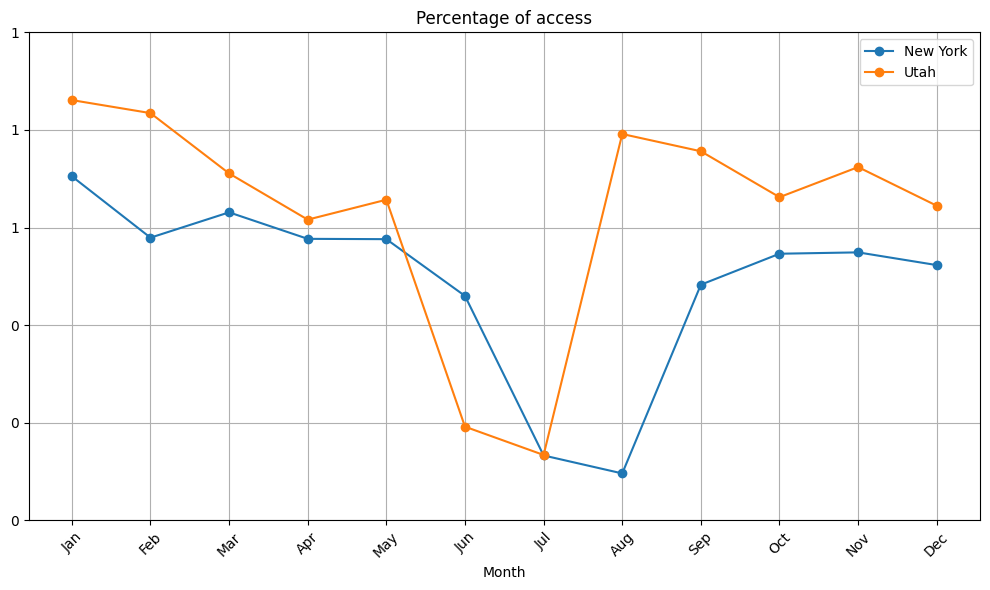

In [ ]:
from cProfile import label
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Dữ liệu
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
pct_acc = [jan, feb, mar, apr, may, jun, jul, agu, sep, oct, nov, dec]#Dữ liệu trung bình các tháng của biến pct_access ở New York
# Dữ liệu 2
pct_acc1 = [jan2, feb2, mar2, apr2, may2, jun2, jul2, agu2, sep2, oct2, nov2, dec2]#Dữ liệu trung bình các tháng của biến pct_access ở Utah
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Vẽ biểu đồ đường
plt.plot(months, pct_acc, label= 'New York', marker='o', linestyle='-')
plt.plot(months, pct_acc1, label= 'Utah', marker='o', linestyle='-')

# Định dạng định tuyến cho trục y
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:,.0f}'.format(x)))

# Thêm tiêu đề và nhãn
plt.title('Percentage of access')
plt.xlabel('Month')

# Mở rộng trục y
plt.ylim(0,1)
plt.legend()

# Hiển thị biểu đồ
plt.xticks(rotation=45)  # Xoay nhãn trục x để dễ đọc
plt.grid(True)  # Thêm lưới
plt.tight_layout()  # Đảm bảo không bị cắt bớt các nhãn
plt.show()

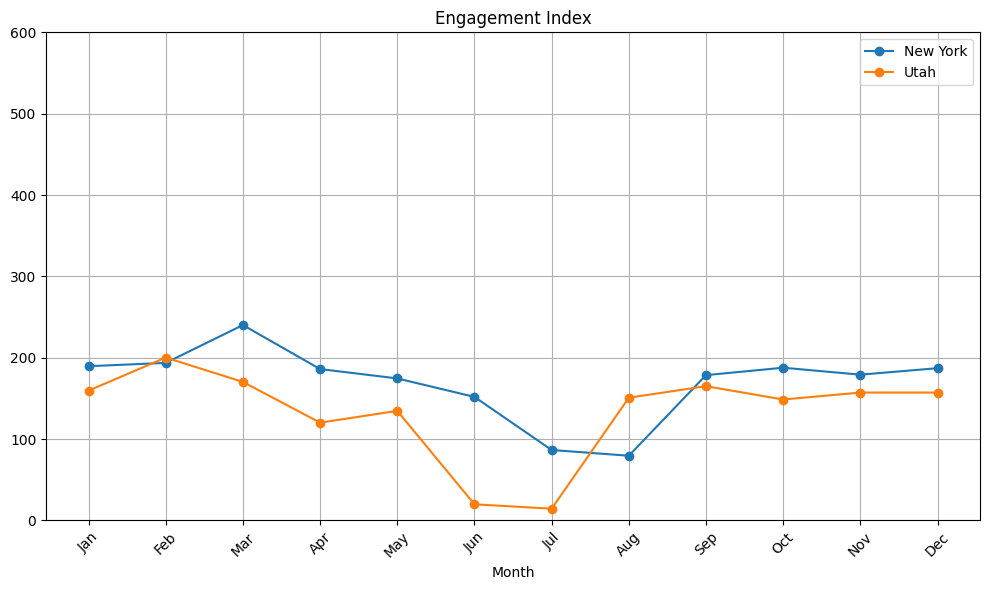

In [ ]:
from cProfile import label
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Dữ liệu
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
engage= [jan1, feb1, mar1, apr1, may1, jun1, jul1, agu1, sep1, oct1, nov1, dec1]#Dữ liệu trung bình các tháng của biến engagement_index ở New York
# Dữ liệu 2
engage1 = [jan3, feb3, mar3, apr3, may3, jun3, jul3, agu3, sep3, oct3, nov3, dec3]#Dữ liệu trung bình các tháng của biến engagement_index ở Utah
# Dữ liệu 2

# Vẽ biểu đồ đường
plt.plot(months, engage,label= 'New York', marker='o', linestyle='-')
plt.plot(months, engage1, label= 'Utah', marker='o', linestyle='-')

# Định dạng định tuyến cho trục y
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:,.0f}'.format(x)))

# Thêm tiêu đề và nhãn
plt.title('Engagement Index')
plt.xlabel('Month')

# Mở rộng trục y để có thể chứa tối đa
plt.ylim(0,600)
plt.legend()
# Hiển thị biểu đồ
plt.xticks(rotation=45)  # Xoay nhãn trục x để dễ đọc
plt.grid(True)  # Thêm lưới
plt.tight_layout()  # Đảm bảo không bị cắt bớt các nhãn
plt.show()


# Phân tích
Hình ảnh dưới đây so sánh tỷ lệ truy cập (màu cam) và chỉ số tương tác (màu xanh lam) của học sinh New York và Utah. Trước đại dịch, cả hai chỉ số đều thấp hơn ở New York, cho thấy sự chênh lệch rõ ràng về việc hoàn thành bài tập về nhà. Sau khi áp dụng học tập từ xa, tỷ lệ truy cập của học sinh New York giảm xuống dưới 10% và chỉ số tương tác gần như bằng 0. Ngược lại, tỷ lệ truy cập ở Utah hầu như không thay đổi, cho thấy mức độ chênh lệch kỹ thuật số thấp hơn và học sinh có thể tiếp tục truy cập học tập trực tuyến khi trường học đóng cửa.

Chỉ số tương tác của học sinh Utah tăng đáng kể vào tháng 3 năm 2020, cho thấy sự thành công của việc triển khai học tập từ xa và học sinh vẫn tương tác tốt với nội dung học tập. Tuy nhiên, khi năm học 2020-2021 bắt đầu, các chính sách và hỗ trợ tài chính của chính phủ và địa phương đã tác động đáng kể đến khả năng tiếp cận học tập trực tuyến của học sinh New York. Tỷ lệ truy cập của học sinh New York bắt đầu tăng dần và chỉ số tương tác cũng có xu hướng cải thiện. Mặc

dù chưa đạt được mức độ của Utah, sự chênh lệch kỹ thuật số ở New York đã được thu hẹp đáng kể nhờ những nỗ lực này.

# Kết luận:

· Mức độ chênh lệch kỹ thuật số ảnh hưởng đáng kể đến khả năng học tập trực tuyến của học sinh trong đại dịch COVID-19.

· Các bang có chính sách hỗ trợ hiệu quả có thể giúp thu hẹp khoảng cách kỹ thuật số và đảm bảo tất cả học sinh đều có cơ hội học tập bình đẳng.

· Dữ liệu của New York và Utah cho thấy tầm quan trọng của việc đầu tư vào cơ sở hạ tầng kỹ thuật số và hỗ trợ học tập trực tuyến để đảm bảo khả năng phục hồi của hệ thống giáo dục trong những trường hợp bất ngờ.

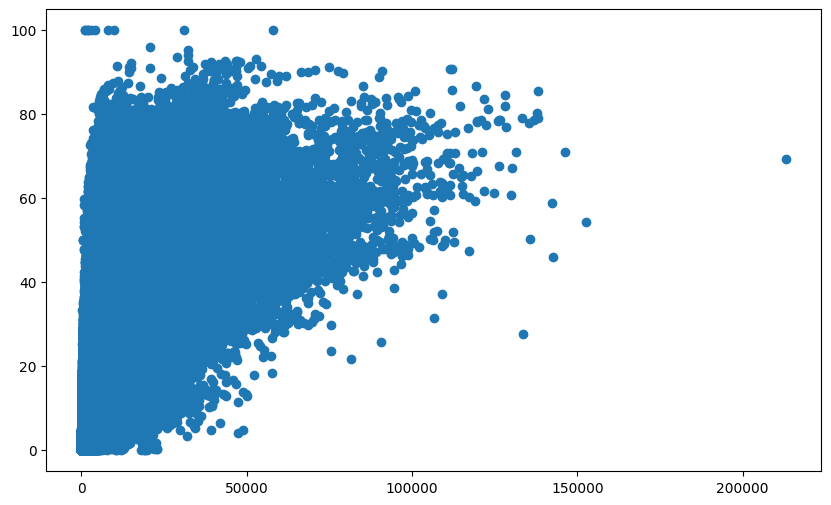

In [ ]:
dt= dt.dropna()
plt.scatter(dt['engagement_index'], dt['pct_access'])
plt.show()
#Lọc dữ liệu nan của tập dữ liệu engagement_data

In [ ]:
dt_uper_eng= dt['engagement_index'].mean() + 3*dt['engagement_index'].std()#Cận dưới của biến engagement_index
dt_lower_eng= dt['engagement_index'].mean() - 3*dt['engagement_index'].std()#Cận trên của biến engagement_index

In [ ]:
dt_new_eng= dt[(dt['engagement_index'] > dt_lower_eng) & (dt['engagement_index'] < dt_uper_eng)]#Tập dữ liệu mới sau khi bỏ đi Outliners của biến engagement_index
dt_new_eng.describe()

,district_id,lp_id,pct_access,engagement_index
count,1.683601e+07,1.683601e+07,1.683601e+07,1.683601e+07
mean,5.295189e+03,5.475424e+04,4.548338e-01,6.524160e+01
std,2.641451e+03,2.665471e+04,2.131961e+00,3.183156e+02
min,1.000000e+03,1.000300e+04,0.000000e+00,1.000000e-02
25%,2.991000e+03,3.085100e+04,1.000000e-02,3.700000e-01
50%,4.949000e+03,5.500700e+04,4.000000e-02,1.890000e+00
75%,7.741000e+03,7.771300e+04,1.500000e-01,1.303000e+01
max,9.927000e+03,9.998400e+04,1.000000e+02,5.214310e+03


In [ ]:
dt_uper_pct= dt['pct_access'].mean() + 3*dt['pct_access'].std()#Cận dưới của biến dữ liệu pct_access
dt_lower_pct= dt['pct_access'].mean() - 3*dt['pct_access'].std()#Cận trên của biến dữ liệu pct_access

In [ ]:
dt_new_pct= dt[(dt['pct_access'] > dt_lower_pct) & (dt['pct_access'] < dt_uper_pct)]#Tập dữ liệu mới sau khi bỏ Outliners của biến pct_access
dt_new_pct

,district_id,time,lp_id,pct_access,engagement_index
1,1000,2020-01-01,17941.0,0.03,0.90
2,1000,2020-01-01,65358.0,0.03,1.20
3,1000,2020-01-01,98265.0,0.57,37.79
5,1000,2020-01-01,90153.0,0.06,3.90
7,1000,2020-01-01,29322.0,0.06,5.10
...,...,...,...,...,...
22324183,9927,2020-12-31,57371.0,0.04,3.94
22324185,9927,2020-12-31,56028.0,0.02,0.20
22324186,9927,2020-12-31,14124.0,0.02,0.99
22324188,9927,2020-12-31,13496.0,0.12,6.51


**Percentage access and Engagement index chung của tất cả các bang**



In [ ]:
jan4= dt_new_pct[dt_new_pct['time'].str.contains('2020-01-')]#Tách dữ liệu thành từng tháng một
jan4_1= dt_new_eng[dt_new_eng['time'].str.contains('2020-01-')]
jan5= jan4['pct_access'].mean()#Lấy ra trung bình từng tháng của biến pct_access
jan5_1 = jan4_1['engagement_index'].mean()#Lấy ra trung bình từng tháng của biến egagement_index

In [ ]:
feb4= dt_new_pct[dt_new_pct['time'].str.contains('2020-02-')]
feb4_1= dt_new_eng[dt_new_eng['time'].str.contains('2020-02-')]
feb5= feb4['pct_access'].mean()
feb5_1 = feb4_1['engagement_index'].mean()

In [ ]:
mar4= dt_new_pct[dt_new_pct['time'].str.contains('2020-03-')]
mar4_1= dt_new_eng[dt_new_eng['time'].str.contains('2020-03-')]
mar5= mar4['pct_access'].mean()
mar5_1 = mar4_1['engagement_index'].mean()

In [ ]:
apr4= dt_new_pct[dt_new_pct['time'].str.contains('2020-04-')]
apr4_1= dt_new_eng[dt_new_eng['time'].str.contains('2020-04-')]
apr5= apr4['pct_access'].mean()
apr5_1 = apr4_1['engagement_index'].mean()

In [ ]:
may4= dt_new_pct[dt_new_pct['time'].str.contains('2020-05-')]
may4_1= dt_new_eng[dt_new_eng['time'].str.contains('2020-05-')]
may5= may4['pct_access'].mean()
may5_1 = may4_1['engagement_index'].mean()

In [ ]:
jun4= dt_new_pct[dt_new_pct['time'].str.contains('2020-06-')]
jun4_1= dt_new_eng[dt_new_eng['time'].str.contains('2020-06-')]
jun5= jun4['pct_access'].mean()
jun5_1 = jun4_1['engagement_index'].mean()

In [ ]:
jul4= dt_new_pct[dt_new_pct['time'].str.contains('2020-07-')]
jul4_1= dt_new_eng[dt_new_eng['time'].str.contains('2020-07-')]
jul5= jul4['pct_access'].mean()
jul5_1 = jul4_1['engagement_index'].mean()

In [ ]:
agu4= dt_new_pct[dt_new_pct['time'].str.contains('2020-08-')]
agu4_1= dt_new_eng[dt_new_eng['time'].str.contains('2020-08-')]
agu5= agu4['pct_access'].mean()
agu5_1 = agu4_1['engagement_index'].mean()

In [ ]:
sep4= dt_new_pct[dt_new_pct['time'].str.contains('2020-09-')]
sep4_1= dt_new_eng[dt_new_eng['time'].str.contains('2020-09-')]
sep5= sep4['pct_access'].mean()
sep5_1 = sep4_1['engagement_index'].mean()

In [ ]:
oct4= dt_new_pct[dt_new_pct['time'].str.contains('2020-10-')]
oct4_1= dt_new_eng[dt_new_eng['time'].str.contains('2020-10-')]
oct5= oct4['pct_access'].mean()
oct5_1 = oct4_1['engagement_index'].mean()

In [ ]:
nov4= dt_new_pct[dt_new_pct['time'].str.contains('2020-11-')]
nov4_1= dt_new_eng[dt_new_eng['time'].str.contains('2020-11-')]
nov5= nov4['pct_access'].mean()
nov5_1 = nov4_1['engagement_index'].mean()

In [ ]:
dec4= dt_new_pct[dt_new_pct['time'].str.contains('2020-12-')]
dec4_1= dt_new_eng[dt_new_eng['time'].str.contains('2020-12-')]
dec5= dec4['pct_access'].mean()
dec5_1 = dec4_1['engagement_index'].mean()

In [ ]:
engage2= [jan5_1, feb5_1, mar5_1, apr5_1, may5_1, jun5_1, jul5_1, agu5_1, sep5_1, oct5_1, nov5_1, dec5_1]
e2= pd.DataFrame(engage2)#Gộp các giá trị trung bình của biến engagement_index vào 1 list
e2

,0
0,68.779784
1,79.914942
2,79.571996
3,66.040631
4,58.355461
5,44.692095
6,36.676019
7,50.960293
8,69.469934
9,67.288789


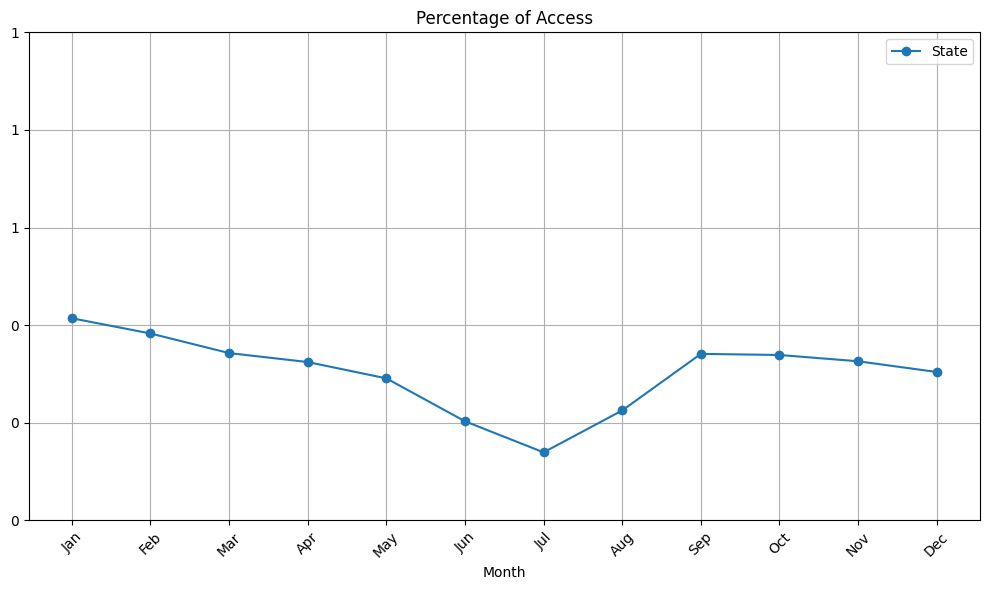

In [ ]:
from cProfile import label
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Dữ liệu
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
engage3= [jan5, feb5, mar5, apr5, may5, jun5, jul5, agu5, sep5, oct5, nov5, dec5]#Gộp các giá trị trung bình từng tháng của biến pct_access vào 1 list

# Vẽ biểu đồ đường
plt.plot(months, engage3,label= 'State', marker='o', linestyle='-')

# Định dạng định tuyến cho trục y
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:,.0f}'.format(x)))

# Thêm tiêu đề và nhãn
plt.title('Percentage of Access')
plt.xlabel('Month')

# Mở rộng trục y để có thể chứa tối đa
plt.ylim(0,1)
plt.legend()
# Hiển thị biểu đồ
plt.xticks(rotation=45)  # Xoay nhãn trục x để dễ đọc
plt.grid(True)  # Thêm lưới
plt.tight_layout()  # Đảm bảo không bị cắt bớt các nhãn
plt.show()


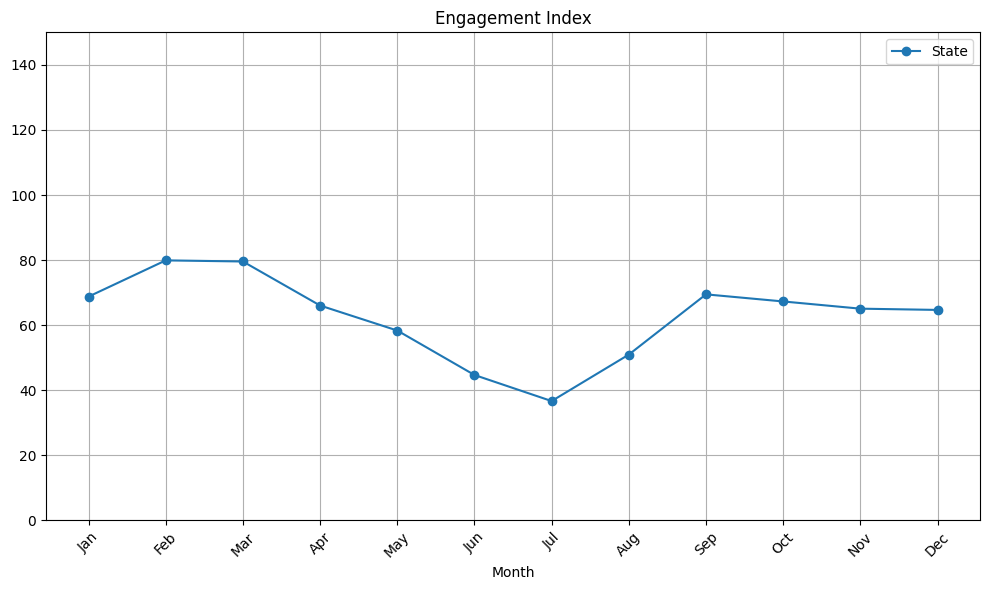

In [ ]:
from cProfile import label
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Dữ liệu
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
engage2= [jan5_1, feb5_1, mar5_1, apr5_1, may5_1, jun5_1, jul5_1, agu5_1, sep5_1, oct5_1, nov5_1, dec5_1]#Gộp các giá trị trung bình từng tháng của biến engagement_index vào 1 list

# Vẽ biểu đồ đường
plt.plot(months, engage2,label= 'State', marker='o', linestyle='-')

# Định dạng định tuyến cho trục y
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:,.0f}'.format(x)))

# Thêm tiêu đề và nhãn
plt.title('Engagement Index')
plt.xlabel('Month')

# Mở rộng trục y để có thể chứa tối đa
plt.ylim(0,150)
plt.legend()
# Hiển thị biểu đồ
plt.xticks(rotation=45)  # Xoay nhãn trục x để dễ đọc
plt.grid(True)  # Thêm lưới
plt.tight_layout()  # Đảm bảo không bị cắt bớt các nhãn
plt.show()


#Nhận xét
- Tỷ lệ tương tác: Chúng ta thấy rằng tỷ lệ tương tác đã tăng mạnh vào giữa tháng. Lúc này, các trường học đã cảnh báo về một đợt cận chiến có thể xảy ra. Tỷ lệ tương tác đạt đỉnh vào cuối tháng 3 và tháng 4, khi học sinh truy cập các trang web thường xuyên hơn để duy trì tương tác với nội dung từ xa.
- Tỷ lệ tiếp cận: Từ khi đại dịch được tuyên bố và các trường học đóng cửa, tỷ lệ học sinh truy cập các trang web đã giảm tới một nửa. Tuy nhiên, sau đó, tỷ lệ tiếp cận tăng trở lại, nhưng không đạt đến mức trước đại dịch. Điều này cho thấy nhiều học sinh không có khả năng truy cập tức thì vào thiết bị kỹ thuật số hoặc kết nối Internet phù hợp để học tập từ xa.
- Năm học 2020/2021: Đầu năm học này, cả tỷ lệ tương tác và tỷ lệ tiếp cận đã tăng lên trên mức trước đại dịch. Điều này là kết quả của việc lập kế hoạch học tập từ xa cẩn thận trong mùa hè, cũng như các chính sách hỗ trợ việc tiếp cận thiết bị và Internet cho học sinh có nhu cầu.